In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path
import seaborn as sns

# Exploration

In [126]:
df_genera_counts = pd.read_csv('processed_data/ERAWIJANTARI_GASTRIC_CANCER_2020/genera.counts.tsv', sep = '\t')
df_genera = pd.read_csv('processed_data/ERAWIJANTARI_GASTRIC_CANCER_2020/genera.tsv', sep = '\t')
df_metadata = pd.read_csv('processed_data/ERAWIJANTARI_GASTRIC_CANCER_2020/metadata.tsv', sep = '\t')
df_mtb_map = pd.read_csv('processed_data/ERAWIJANTARI_GASTRIC_CANCER_2020/mtb.map.tsv', sep = '\t')
df_mtb = pd.read_csv('processed_data/ERAWIJANTARI_GASTRIC_CANCER_2020/mtb.tsv', sep = '\t')
df_species_counts = pd.read_csv('processed_data/ERAWIJANTARI_GASTRIC_CANCER_2020/species.counts.tsv', sep = '\t')
df_species = pd.read_csv('processed_data/ERAWIJANTARI_GASTRIC_CANCER_2020/species.tsv', sep = '\t')


df_mtb_2 = pd.read_csv('processed_data/SINHA_CRC_2016/mtb.tsv', sep = '\t')

# df_genera

In [127]:
df_genera.info()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Columns: 10528 entries, Sample to d__Bacteria;p__Actinobacteriota;c__Thermoleophilia;o__Solirubrobacterales;f__Thermoleophilaceae;g__Thermoleophilum
dtypes: float64(10424), int64(103), str(1)
memory usage: 7.7 MB


In [128]:
df_genera.head(10)

,Sample,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhodobacterales;f__Rhodobacteraceae;g__Oceaniglobus,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__CAG-272;g__Flemingibacterium,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__F0428,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Lachnoanaerobaculum,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Carnobacteriaceae;g__Carnobacterium_A,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__GCA-900066755,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Monoglobales;f__Monoglobaceae;g__Monoglobus,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhizobiales;f__Rhizobiaceae;g__Pararhizobium,d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;g__PD-1,...,d__Bacteria;p__Fermentibacterota;c__Fermentibacteria;o__Fermentibacterales;f__Fermentibacteraceae;g__JAFGKQ01,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhodobacterales;f__Rhodobacteraceae;g__Qingshengfaniella,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhodobacterales;f__Rhodobacteraceae;g__Fuscovulum,d__Bacteria;p__Spirochaetota;c__Spirochaetia;o__Treponematales;f__Termitinemataceae;g__SZUA-426,d__Bacteria;p__Patescibacteria;c__Paceibacteria;o__Paceibacterales;f__UBA10102;g__VMEU01,d__Bacteria;p__Gemmatimonadota;c__Gemmatimonadetes;o__Longimicrobiales;f__UBA6960;g__SLCK01,d__Bacteria;p__Actinobacteriota;c__Thermoleophilia;o__Solirubrobacterales;f__Thermoleophilaceae;g__JACCZP01,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__DSM-16000;f__Inquilinaceae;g__JABDIP01,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Holosporales;f__Hepatobacteraceae;g__Hepatobacter,d__Bacteria;p__Actinobacteriota;c__Thermoleophilia;o__Solirubrobacterales;f__Thermoleophilaceae;g__Thermoleophilum
0,10776.Healthy,3.239561e-07,8.003622e-07,0.000007,0.000030,4.573498e-07,0.000011,2.286749e-06,1.009981e-06,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,10850.Healthy,0.000000e+00,7.197257e-07,0.000002,0.000014,1.640975e-06,0.000007,8.636709e-07,2.878903e-07,0.000004,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,10543.Healthy,0.000000e+00,3.425342e-06,0.000008,0.000027,1.251567e-06,0.000157,6.126092e-06,3.392406e-06,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,10246.Healthy,0.000000e+00,0.000000e+00,0.000003,0.000018,7.985710e-07,0.000014,1.443571e-06,1.074999e-06,0.000002,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,10156.Gastrectomy,3.901257e-07,2.089959e-06,0.000101,0.000080,1.226109e-06,0.000013,4.570044e-06,0.000000e+00,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,10684.Healthy,0.000000e+00,6.090974e-04,0.000003,0.000020,1.127079e-06,0.000044,7.414996e-06,9.194594e-07,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,10463.Healthy,8.605910e-07,5.136653e-06,0.000014,0.000080,3.227216e-06,0.000084,1.218274e-05,9.143780e-07,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,10100.Healthy,0.000000e+00,3.565426e-07,0.000005,0.000028,2.088321e-06,0.000008,1.680844e-06,3.310753e-07,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,10342.Gastrectomy,0.000000e+00,6.215932e-05,0.000030,0.000069,1.261051e-06,0.000065,2.075480e-05,1.050876e-06,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,10357.Healthy,0.000000e+00,2.882412e-04,0.000009,0.000034,9.888720e-07,0.000064,2.116186e-04,2.127573e-06,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [129]:
df_genera.columns

Index(['Sample',
       'd__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhodobacterales;f__Rhodobacteraceae;g__Oceaniglobus',
       'd__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__CAG-272;g__Flemingibacterium',
       'd__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__F0428',
       'd__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Lachnoanaerobaculum',
       'd__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Carnobacteriaceae;g__Carnobacterium_A',
       'd__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__GCA-900066755',
       'd__Bacteria;p__Firmicutes_A;c__Clostridia;o__Monoglobales;f__Monoglobaceae;g__Monoglobus',
       'd__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhizobiales;f__Rhizobiaceae;g__Pararhizobium',
       'd__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;g__PD-1',
       ...
     

In [130]:
df_genera.describe()

,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhodobacterales;f__Rhodobacteraceae;g__Oceaniglobus,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__CAG-272;g__Flemingibacterium,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__F0428,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Lachnoanaerobaculum,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Carnobacteriaceae;g__Carnobacterium_A,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__GCA-900066755,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Monoglobales;f__Monoglobaceae;g__Monoglobus,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhizobiales;f__Rhizobiaceae;g__Pararhizobium,d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;g__PD-1,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__CAG-272;g__CAG-448,...,d__Bacteria;p__Fermentibacterota;c__Fermentibacteria;o__Fermentibacterales;f__Fermentibacteraceae;g__JAFGKQ01,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhodobacterales;f__Rhodobacteraceae;g__Qingshengfaniella,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhodobacterales;f__Rhodobacteraceae;g__Fuscovulum,d__Bacteria;p__Spirochaetota;c__Spirochaetia;o__Treponematales;f__Termitinemataceae;g__SZUA-426,d__Bacteria;p__Patescibacteria;c__Paceibacteria;o__Paceibacterales;f__UBA10102;g__VMEU01,d__Bacteria;p__Gemmatimonadota;c__Gemmatimonadetes;o__Longimicrobiales;f__UBA6960;g__SLCK01,d__Bacteria;p__Actinobacteriota;c__Thermoleophilia;o__Solirubrobacterales;f__Thermoleophilaceae;g__JACCZP01,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__DSM-16000;f__Inquilinaceae;g__JABDIP01,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Holosporales;f__Hepatobacteraceae;g__Hepatobacter,d__Bacteria;p__Actinobacteriota;c__Thermoleophilia;o__Solirubrobacterales;f__Thermoleophilaceae;g__Thermoleophilum
count,9.600000e+01,96.000000,9.600000e+01,96.000000,9.600000e+01,96.000000,9.600000e+01,9.600000e+01,96.000000,96.000000,...,9.600000e+01,9.600000e+01,9.600000e+01,9.600000e+01,9.600000e+01,9.600000e+01,9.600000e+01,9.600000e+01,9.600000e+01,9.600000e+01
mean,3.558214e-07,0.000025,2.147657e-05,0.000077,1.563392e-06,0.000088,5.372044e-05,1.070585e-06,0.000002,0.000054,...,1.889806e-09,5.154017e-09,2.920610e-09,2.405208e-09,2.233407e-09,1.718006e-09,1.889806e-09,2.405208e-09,2.284947e-08,2.920610e-09
std,1.201808e-06,0.000081,3.675926e-05,0.000162,1.559300e-06,0.000109,2.146694e-04,1.105308e-06,0.000007,0.000211,...,1.851624e-08,5.049884e-08,2.861601e-08,2.356613e-08,2.188283e-08,1.683295e-08,1.851624e-08,2.356613e-08,2.238782e-07,2.861601e-08
min,0.000000e+00,0.000000,4.105312e-07,0.000006,0.000000e+00,0.000003,4.742927e-07,0.000000e+00,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000002,6.583796e-06,0.000029,6.787712e-07,0.000028,3.181369e-06,3.802108e-07,0.000000,0.000003,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000003,1.083822e-05,0.000043,1.134147e-06,0.000055,6.509232e-06,7.030941e-07,0.000000,0.000008,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2.244671e-07,0.000009,2.014461e-05,0.000059,1.808510e-06,0.000096,1.285204e-05,1.417239e-06,0.000002,0.000027,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,8.892480e-06,0.000609,2.807935e-04,0.001265,8.147470e-06,0.000782,1.696173e-03,6.424975e-06,0.000053,0.001921,...,1.814214e-07,4.947856e-07,2.803785e-07,2.309000e-07,2.144071e-07,1.649285e-07,1.814214e-07,2.309000e-07,2.193550e-06,2.803785e-07


# df_genera_count

In [131]:
df_genera_counts.info()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Columns: 10528 entries, Sample to d__Bacteria;p__Actinobacteriota;c__Thermoleophilia;o__Solirubrobacterales;f__Thermoleophilaceae;g__Thermoleophilum
dtypes: int64(10527), str(1)
memory usage: 7.7 MB


In [132]:
df_genera_counts.head(10)

,Sample,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhodobacterales;f__Rhodobacteraceae;g__Oceaniglobus,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__CAG-272;g__Flemingibacterium,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__F0428,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Lachnoanaerobaculum,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Carnobacteriaceae;g__Carnobacterium_A,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__GCA-900066755,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Monoglobales;f__Monoglobaceae;g__Monoglobus,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhizobiales;f__Rhizobiaceae;g__Pararhizobium,d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;g__PD-1,...,d__Bacteria;p__Fermentibacterota;c__Fermentibacteria;o__Fermentibacterales;f__Fermentibacteraceae;g__JAFGKQ01,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhodobacterales;f__Rhodobacteraceae;g__Qingshengfaniella,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhodobacterales;f__Rhodobacteraceae;g__Fuscovulum,d__Bacteria;p__Spirochaetota;c__Spirochaetia;o__Treponematales;f__Termitinemataceae;g__SZUA-426,d__Bacteria;p__Patescibacteria;c__Paceibacteria;o__Paceibacterales;f__UBA10102;g__VMEU01,d__Bacteria;p__Gemmatimonadota;c__Gemmatimonadetes;o__Longimicrobiales;f__UBA6960;g__SLCK01,d__Bacteria;p__Actinobacteriota;c__Thermoleophilia;o__Solirubrobacterales;f__Thermoleophilaceae;g__JACCZP01,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__DSM-16000;f__Inquilinaceae;g__JABDIP01,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Holosporales;f__Hepatobacteraceae;g__Hepatobacter,d__Bacteria;p__Actinobacteriota;c__Thermoleophilia;o__Solirubrobacterales;f__Thermoleophilaceae;g__Thermoleophilum
0,10776.Healthy,17,42,374,1569,24,597,120,53,0,...,0,0,0,0,0,0,0,0,0,0
1,10850.Healthy,0,25,75,502,57,237,30,10,154,...,0,0,0,0,0,0,0,0,0,0
2,10543.Healthy,0,104,239,815,38,4763,186,103,0,...,0,0,0,0,0,0,0,0,0,0
3,10246.Healthy,0,0,108,580,26,446,47,35,57,...,0,0,0,0,0,0,0,0,0,0
4,10156.Gastrectomy,14,75,3622,2875,44,461,164,0,0,...,0,0,0,0,0,0,0,0,0,0
5,10684.Healthy,0,20536,98,685,38,1488,250,31,0,...,0,0,0,0,0,0,0,0,0,0
6,10463.Healthy,32,191,514,2982,120,3118,453,34,0,...,0,0,0,0,0,0,0,0,0,0
7,10100.Healthy,0,14,204,1096,82,326,66,13,0,...,0,0,0,0,0,0,0,0,0,0
8,10342.Gastrectomy,0,2366,1146,2621,48,2463,790,40,0,...,0,0,0,0,0,0,0,0,0,0
9,10357.Healthy,0,9619,299,1123,33,2137,7062,71,0,...,0,0,0,0,0,0,0,0,0,0


In [133]:
df_genera_counts.columns

Index(['Sample',
       'd__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhodobacterales;f__Rhodobacteraceae;g__Oceaniglobus',
       'd__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__CAG-272;g__Flemingibacterium',
       'd__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__F0428',
       'd__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Lachnoanaerobaculum',
       'd__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Carnobacteriaceae;g__Carnobacterium_A',
       'd__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__GCA-900066755',
       'd__Bacteria;p__Firmicutes_A;c__Clostridia;o__Monoglobales;f__Monoglobaceae;g__Monoglobus',
       'd__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhizobiales;f__Rhizobiaceae;g__Pararhizobium',
       'd__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;g__PD-1',
       ...
     

In [134]:
df_genera_counts.describe()

,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhodobacterales;f__Rhodobacteraceae;g__Oceaniglobus,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__CAG-272;g__Flemingibacterium,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__F0428,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Lachnoanaerobaculum,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Carnobacteriaceae;g__Carnobacterium_A,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__GCA-900066755,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Monoglobales;f__Monoglobaceae;g__Monoglobus,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhizobiales;f__Rhizobiaceae;g__Pararhizobium,d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;g__PD-1,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__CAG-272;g__CAG-448,...,d__Bacteria;p__Fermentibacterota;c__Fermentibacteria;o__Fermentibacterales;f__Fermentibacteraceae;g__JAFGKQ01,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhodobacterales;f__Rhodobacteraceae;g__Qingshengfaniella,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhodobacterales;f__Rhodobacteraceae;g__Fuscovulum,d__Bacteria;p__Spirochaetota;c__Spirochaetia;o__Treponematales;f__Termitinemataceae;g__SZUA-426,d__Bacteria;p__Patescibacteria;c__Paceibacteria;o__Paceibacterales;f__UBA10102;g__VMEU01,d__Bacteria;p__Gemmatimonadota;c__Gemmatimonadetes;o__Longimicrobiales;f__UBA6960;g__SLCK01,d__Bacteria;p__Actinobacteriota;c__Thermoleophilia;o__Solirubrobacterales;f__Thermoleophilaceae;g__JACCZP01,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__DSM-16000;f__Inquilinaceae;g__JABDIP01,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Holosporales;f__Hepatobacteraceae;g__Hepatobacter,d__Bacteria;p__Actinobacteriota;c__Thermoleophilia;o__Solirubrobacterales;f__Thermoleophilaceae;g__Thermoleophilum
count,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,...,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000
mean,11.802083,961.177083,750.385417,2406.833333,58.041667,2984.187500,1999.447917,36.052083,74.322917,2266.916667,...,0.114583,0.312500,0.177083,0.145833,0.135417,0.104167,0.114583,0.145833,1.385417,0.177083
std,37.387197,3234.383374,1226.978646,4895.775497,70.743706,2991.159178,7937.148398,33.519631,194.371944,9417.211937,...,1.122683,3.061862,1.735055,1.428869,1.326807,1.020621,1.122683,1.428869,13.574256,1.735055
min,0.000000,0.000000,15.000000,159.000000,0.000000,69.000000,13.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,47.500000,223.500000,989.000000,24.000000,964.500000,96.750000,14.000000,0.000000,123.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,110.000000,409.500000,1543.000000,38.000000,2047.500000,218.500000,28.000000,0.000000,245.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,10.250000,310.500000,737.500000,2254.000000,62.750000,3688.500000,516.000000,44.750000,47.250000,905.750000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,254.000000,20536.000000,9225.000000,45323.000000,494.000000,14141.000000,55845.000000,140.000000,1254.000000,84978.000000,...,11.000000,30.000000,17.000000,14.000000,13.000000,10.000000,11.000000,14.000000,133.000000,17.000000


# df_metadata

In [135]:
df_metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 52 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Dataset                                96 non-null     str    
 1   Sample                                 96 non-null     str    
 2   Subject                                96 non-null     str    
 3   Study.Group                            96 non-null     str    
 4   Age                                    96 non-null     int64  
 5   Age.Units                              96 non-null     str    
 6   Gender                                 96 non-null     str    
 7   BMI                                    96 non-null     float64
 8   DOI                                    96 non-null     str    
 9   Publication.Name                       96 non-null     str    
 10  Surgery_Type                           96 non-null     str    
 11  Reconstruction     

In [136]:
df_metadata.head(10)

,Dataset,Sample,Subject,Study.Group,Age,Age.Units,Gender,BMI,DOI,Publication.Name,...,Chronic hepatitis and liver cirrhosis,Gallstone,Ureteral or kidney stones,Gout...46,Hip fracture,Arm or wrist fracture,Femur base fractures,Other diseases,Subject.Num,Shared.w.YACHIDA_2019
0,ERAWIJANTARI_GASTRIC_CANCER_2020,10025.Healthy,10025.Healthy,Healthy,40,Years,Male,25.000000,10.1136/gutjnl-2019-319188,Influence of gastrectomy for gastric cancer tr...,...,No,No,No,No,No,No,No,No,10025,True
1,ERAWIJANTARI_GASTRIC_CANCER_2020,10036.Healthy,10036.Healthy,Healthy,64,Years,Female,21.155294,10.1136/gutjnl-2019-319188,Influence of gastrectomy for gastric cancer tr...,...,No,No,No,No,No,No,No,Yes,10036,True
2,ERAWIJANTARI_GASTRIC_CANCER_2020,10037.Healthy,10037.Healthy,Healthy,66,Years,Female,25.410900,10.1136/gutjnl-2019-319188,Influence of gastrectomy for gastric cancer tr...,...,No,No,No,No,No,No,No,No,10037,True
3,ERAWIJANTARI_GASTRIC_CANCER_2020,10048.Healthy,10048.Healthy,Healthy,77,Years,Female,23.634033,10.1136/gutjnl-2019-319188,Influence of gastrectomy for gastric cancer tr...,...,No,No,No,No,No,No,No,Yes,10048,True
4,ERAWIJANTARI_GASTRIC_CANCER_2020,10058.Healthy,10058.Healthy,Healthy,59,Years,Male,28.841532,10.1136/gutjnl-2019-319188,Influence of gastrectomy for gastric cancer tr...,...,No,No,No,No,No,No,No,No,10058,True
5,ERAWIJANTARI_GASTRIC_CANCER_2020,10060.Healthy,10060.Healthy,Healthy,73,Years,Female,20.703125,10.1136/gutjnl-2019-319188,Influence of gastrectomy for gastric cancer tr...,...,No,Yes,No,No,No,Yes,No,No,10060,True
6,ERAWIJANTARI_GASTRIC_CANCER_2020,10064.Gastrectomy,10064.Gastrectomy,Gastrectomy,64,Years,Male,18.818924,10.1136/gutjnl-2019-319188,Influence of gastrectomy for gastric cancer tr...,...,No,No,No,No,No,No,No,Yes,10064,False
7,ERAWIJANTARI_GASTRIC_CANCER_2020,10080.Healthy,10080.Healthy,Healthy,74,Years,Male,20.685150,10.1136/gutjnl-2019-319188,Influence of gastrectomy for gastric cancer tr...,...,No,No,No,Yes,NoYes,No,No,No,10080,True
8,ERAWIJANTARI_GASTRIC_CANCER_2020,10100.Healthy,10100.Healthy,Healthy,70,Years,Male,23.661439,10.1136/gutjnl-2019-319188,Influence of gastrectomy for gastric cancer tr...,...,No,No,No,Yes,No,No,No,No,10100,True
9,ERAWIJANTARI_GASTRIC_CANCER_2020,10105.Healthy,10105.Healthy,Healthy,66,Years,Female,19.555556,10.1136/gutjnl-2019-319188,Influence of gastrectomy for gastric cancer tr...,...,No,No,No,No,No,No,No,No,10105,True


In [137]:
df_metadata.describe()

,Age,BMI,Glucose,Total_Cholesterol,Subject.Num
count,96.000000,96.000000,84.000000,82.000000,96.000000
mean,62.395833,22.243418,103.250000,198.682927,10401.802083
std,11.304847,2.991515,14.412072,33.015850,238.031604
min,40.000000,15.614727,59.000000,107.000000,10025.000000
25%,52.000000,20.407763,94.750000,176.000000,10206.500000
50%,65.000000,22.055121,100.000000,199.500000,10356.000000
75%,72.000000,24.280975,111.250000,217.750000,10625.250000
max,79.000000,33.139755,147.000000,304.000000,10850.000000


In [138]:
healthy_people = df_metadata[df_metadata['Study.Group'] == 'Healthy']
people_with_a_condition = df_metadata[df_metadata['Study.Group'] != 'Healthy']

In [139]:
healthy_people.shape, people_with_a_condition.shape

((54, 52), (42, 52))

In [140]:
diseases = list(df_metadata.columns)

In [141]:
diseases

['Dataset',
 'Sample',
 'Subject',
 'Study.Group',
 'Age',
 'Age.Units',
 'Gender',
 'BMI',
 'DOI',
 'Publication.Name',
 'Surgery_Type',
 'Reconstruction',
 'SmokingStatus',
 'Drinking Status',
 'AlcoholConsumption',
 'complication',
 'Glucose',
 'Total_Cholesterol',
 'High blood pressure',
 'Cholesterol',
 'DiabetesMed',
 'Gout...22',
 'Gastric acid medication',
 'Analgesic',
 'Anticoagulant',
 'Others',
 'Lung cancer',
 'Liver cancer',
 'Breast cancer',
 'Uterine cancer',
 'Other cancers',
 'Stroke',
 'Cardiac infarction',
 'Angina',
 'Hypertension',
 'Diabetes',
 'Dyslipidemia',
 'Cataract',
 'Stomach ulcer',
 'Stomach polyps',
 'Duodenal ulcers',
 'Colorectal polyps',
 'Chronic hepatitis and liver cirrhosis',
 'Gallstone',
 'Ureteral or kidney stones',
 'Gout...46',
 'Hip fracture',
 'Arm or wrist fracture',
 'Femur base fractures',
 'Other diseases',
 'Subject.Num',
 'Shared.w.YACHIDA_2019']

# df_mtb_map

In [142]:
df_mtb_map.info()

<class 'pandas.DataFrame'>
RangeIndex: 524 entries, 0 to 523
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Compound                    524 non-null    str  
 1   KEGG                        506 non-null    str  
 2   HMDB                        490 non-null    str  
 3   High.Confidence.Annotation  524 non-null    bool 
dtypes: bool(1), str(3)
memory usage: 12.9 KB


In [143]:
df_mtb_map.head(10)

,Compound,KEGG,HMDB,High.Confidence.Annotation
0,C03173_(Methylthio)acetate,C03173,HMDB0035646,True
1,C03969_1-Amino-1-cyclopentanecarboxylate,C03969,HMDB0062225,True
2,C01234_1-Aminocyclopropane-1-carboxylate,C01234,HMDB0036458,True
3,C03782_1-Aminoethylphosphonate,C03782,HMDB0247130,True
4,C11118_1-Methyl-2-pyrrolidinone,C11118,HMDB0002039,True
5,C02494_1-Methyladenosine,C02494,HMDB0003331,True
6,C05127_1-Methylhistamine,C05127,HMDB0000898,True
7,C02918_1-Methylnicotinamide,C02918,HMDB0000699,True
8,"C00986_1,3-Diaminopropane",C00986,HMDB0000002,True
9,C02774_10-Hydroxydecanoate,C02774,HMDB0244272,True


In [144]:
df_mtb_map.describe()

,Compound,KEGG,HMDB,High.Confidence.Annotation
count,524,506,490,524
unique,524,505,486,2
top,C03173_(Methylthio)acetate,C02567,HMDB0000807,True
freq,1,2,2,503


# df_mtb

In [145]:
df_mtb.info()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Columns: 525 entries, Sample to _Diethyl-2-phenylacetamide
dtypes: float64(409), int64(115), str(1)
memory usage: 393.9 KB


In [146]:
df_mtb.head(10)

,Sample,-_2-Hydroxyisobutyrate,-_2-Hydroxyoctanoate,-_2-Hydroxypentanoate,-_2-Oxooctanoate,-_3-Indoxyl sulfate,-_4-Oxohexanoate,-_4-Oxopentanoate,-_Cysteine-glutathione disulphide,-_Cysteine-glutathione disulphide -Divalent,...,C11284_3-Indolebutyrate,C11331_Leu-Leu-Tyr,C11527_4-Hydroxymandelate,C15587_Purine,C16741_5-Hydroxylysine,C17714_Heptanoate,C17715_Undecanoate,_3-Aminopyrrolidine,_Diazoxide,_Diethyl-2-phenylacetamide
0,10776.Healthy,0.000000,0.000000,544.606822,0,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.0,48.262346,0.000000,0.000000,0,123.440237,0
1,10850.Healthy,0.000000,0.000000,574.111341,0,0.000000,0.0,0.000000,0.0,2.776857,...,0.000000,6.161976,0.000000,0.0,368.661127,0.000000,0.000000,0,122.646971,0
2,10543.Healthy,0.000000,0.000000,0.000000,0,0.000000,0.0,0.000000,0.0,0.000000,...,60.089022,0.000000,62.652325,0.0,109.446543,0.000000,0.000000,0,0.000000,0
3,10246.Healthy,0.000000,0.000000,464.163389,0,0.000000,0.0,0.000000,0.0,2.806007,...,0.000000,0.000000,0.000000,0.0,916.588182,0.000000,0.000000,0,118.245341,0
4,10156.Gastrectomy,0.000000,0.000000,0.000000,0,0.000000,0.0,0.000000,7.7,0.000000,...,0.000000,0.000000,0.000000,0.0,27.000000,0.000000,0.000000,0,0.000000,0
5,10684.Healthy,0.000000,0.000000,47.789856,0,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.935912,0.000000,0.0,31.182017,403.901108,0.000000,0,0.000000,0
6,10463.Healthy,95.421748,0.000000,411.867255,0,138.480625,0.0,0.000000,0.0,0.000000,...,851.128482,0.000000,268.237435,0.0,136.426234,0.000000,0.000000,0,0.000000,0
7,10100.Healthy,0.000000,1210.109948,0.000000,0,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,136.306382,0.0,948.200067,0.000000,0.000000,0,0.000000,0
8,10342.Gastrectomy,18.383375,0.000000,112.451066,0,8.022035,0.0,127.602967,0.0,0.000000,...,4656.092925,0.000000,0.000000,0.0,11.898742,0.000000,12.612651,0,0.000000,0
9,10357.Healthy,0.000000,0.000000,0.000000,0,0.000000,0.0,0.000000,0.0,0.000000,...,149.929170,0.000000,0.000000,0.0,24.401224,0.000000,0.000000,0,0.000000,0


In [147]:
df_mtb.columns

Index(['Sample', '-_2-Hydroxyisobutyrate', '-_2-Hydroxyoctanoate',
       '-_2-Hydroxypentanoate', '-_2-Oxooctanoate', '-_3-Indoxyl sulfate',
       '-_4-Oxohexanoate', '-_4-Oxopentanoate',
       '-_Cysteine-glutathione disulphide',
       '-_Cysteine-glutathione disulphide -Divalent',
       ...
       'C11284_3-Indolebutyrate', 'C11331_Leu-Leu-Tyr',
       'C11527_4-Hydroxymandelate', 'C15587_Purine', 'C16741_5-Hydroxylysine',
       'C17714_Heptanoate', 'C17715_Undecanoate', '_3-Aminopyrrolidine',
       '_Diazoxide', '_Diethyl-2-phenylacetamide'],
      dtype='str', length=525)

In [148]:
df_mtb.describe()

,-_2-Hydroxyisobutyrate,-_2-Hydroxyoctanoate,-_2-Hydroxypentanoate,-_2-Oxooctanoate,-_3-Indoxyl sulfate,-_4-Oxohexanoate,-_4-Oxopentanoate,-_Cysteine-glutathione disulphide,-_Cysteine-glutathione disulphide -Divalent,-_N-Acetylvaline,...,C11284_3-Indolebutyrate,C11331_Leu-Leu-Tyr,C11527_4-Hydroxymandelate,C15587_Purine,C16741_5-Hydroxylysine,C17714_Heptanoate,C17715_Undecanoate,_3-Aminopyrrolidine,_Diazoxide,_Diethyl-2-phenylacetamide
count,96.000000,96.000000,96.000000,96.0,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,...,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.0,96.000000,96.0
mean,49.975585,122.197262,166.078052,0.0,26.962916,0.330567,5.281179,2.048958,1.217759,37.654850,...,465.741164,0.417060,132.120894,0.502083,205.126090,67.562916,0.675152,0.0,16.604301,0.0
std,252.693906,422.684549,381.821230,0.0,158.091399,3.238881,29.269355,8.357058,6.469686,84.257559,...,1378.448459,1.884668,461.774571,3.126524,420.095659,187.090382,2.923096,0.0,40.481627,0.0
min,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0
25%,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,17.958039,0.000000,0.000000,0.0,0.000000,0.0
50%,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,13.684289,...,0.000000,0.000000,0.000000,0.000000,35.976016,0.000000,0.000000,0.0,0.000000,0.0
75%,0.000000,9.778226,151.755396,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,38.097876,...,149.715594,0.000000,0.000000,0.000000,164.404211,0.000000,0.000000,0.0,0.000000,0.0
max,2361.245804,3202.598987,2108.900658,0.0,1462.000000,31.734421,235.668432,51.000000,59.388071,584.000000,...,9223.694443,12.638871,4010.766271,26.000000,2815.057950,1070.746436,14.648668,0.0,123.440237,0.0


# df_species_counts

In [149]:
df_species_counts.info()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Columns: 48244 entries, Sample to d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhodospirillales;f__Magnetospirillaceae;g__Phaeospirillum;s__Phaeospirillum sp002105535
dtypes: int64(48243), str(1)
memory usage: 35.3 MB


In [150]:
df_species_counts.head(10)

,Sample,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Marinifilaceae;g__Odoribacter;s__Odoribacter sp905193145,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Streptococcaceae;g__Streptococcus;s__Streptococcus oralis_S,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Prevotella;s__Prevotella sp900546575,d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;g__Kosakonia;s__Kosakonia sp014490785,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__JAGTTR01;s__JAGTTR01 sp018223385,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Coprococcus;s__Coprococcus sp016297325,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__Ruminococcaceae;g__UMGS363;s__UMGS363 sp900768245,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Prevotella;s__Prevotella sp002372235,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Streptococcaceae;g__Streptococcus;s__Streptococcus thoraltensis,...,d__Bacteria;p__Actinobacteriota;c__Actinomycetia;o__Nanopelagicales;f__Nanopelagicaceae;g__Planktophila;s__Planktophila sp903894425,d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Xanthomonadales;f__Xanthomonadaceae;g__Lysobacter_B;s__Lysobacter_B sp018242405,d__Bacteria;p__Planctomycetota;c__UBA8108;o__UBA1146;f__UBA1146;g__UBA12191;s__UBA12191 sp003540375,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhodobacterales;f__Rhodobacteraceae;g__Qingshengfaniella;s__Qingshengfaniella alkalisoli,d__Bacteria;p__Acidobacteriota;c__Aminicenantia;o__UBA2199;f__UBA2199;g__UBA2199;s__UBA2199 sp002327965,d__Bacteria;p__Verrucomicrobiota;c__Kiritimatiellae;o__RFP12;f__UBA1067;g__RUG572;s__RUG572 sp017563185,d__Bacteria;p__Patescibacteria;c__Paceibacteria;o__Paceibacterales;f__UBA10102;g__VMEU01;s__VMEU01 sp007375675,d__Bacteria;p__Patescibacteria;c__Saccharimonadia;o__CAILAD01;f__BJGX01;g__BJGX01;s__BJGX01 sp014191035,d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Arenicellales;f__LS-SOB;g__WLWV01;s__WLWV01 sp012103395,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhodospirillales;f__Magnetospirillaceae;g__Phaeospirillum;s__Phaeospirillum sp002105535
0,10776.Healthy,1913,111,3902,0,898,44,757,0,23,...,0,0,0,0,0,0,0,0,0,0
1,10850.Healthy,778,23,33,72,877,10,106,0,0,...,0,0,0,0,0,0,0,0,0,0
2,10543.Healthy,1348,74,2177,0,1413,45,636,0,0,...,0,0,0,0,0,0,0,0,0,0
3,10246.Healthy,1290,29,1021,46,945,15,95,0,0,...,0,0,0,0,0,0,0,0,0,0
4,10156.Gastrectomy,1136,158,3108,305,671,1222,1117,0,381,...,0,0,0,0,0,0,0,0,0,0
5,10684.Healthy,5027,0,17352,0,8394,250,11992,19,0,...,0,0,0,0,0,0,0,0,0,0
6,10463.Healthy,4687,259,1001,39,12956,77,2276,0,77,...,0,0,0,0,0,0,0,0,0,0
7,10100.Healthy,4555,31,0,0,767,45,161,0,0,...,0,0,0,0,0,0,0,0,0,0
8,10342.Gastrectomy,1921,140,1994,0,11742,109,2455,29,367,...,0,0,0,0,0,0,0,0,0,0
9,10357.Healthy,4105,144,5384,0,1731,81,1904,0,24,...,0,0,0,0,0,0,0,0,0,0


In [151]:
df_species_counts.columns

Index(['Sample',
       'd__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Marinifilaceae;g__Odoribacter;s__Odoribacter sp905193145',
       'd__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Streptococcaceae;g__Streptococcus;s__Streptococcus oralis_S',
       'd__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Prevotella;s__Prevotella sp900546575',
       'd__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;g__Kosakonia;s__Kosakonia sp014490785',
       'd__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__JAGTTR01;s__JAGTTR01 sp018223385',
       'd__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Coprococcus;s__Coprococcus sp016297325',
       'd__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__Ruminococcaceae;g__UMGS363;s__UMGS363 sp900768245',
       'd__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Ba

In [164]:
df_species_counts.describe()

,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Marinifilaceae;g__Odoribacter;s__Odoribacter sp905193145,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Streptococcaceae;g__Streptococcus;s__Streptococcus oralis_S,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Prevotella;s__Prevotella sp900546575,d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;g__Kosakonia;s__Kosakonia sp014490785,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__JAGTTR01;s__JAGTTR01 sp018223385,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Coprococcus;s__Coprococcus sp016297325,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__Ruminococcaceae;g__UMGS363;s__UMGS363 sp900768245,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Prevotella;s__Prevotella sp002372235,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Streptococcaceae;g__Streptococcus;s__Streptococcus thoraltensis,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Anaerostipes;s__Anaerostipes sp000508985,...,d__Bacteria;p__Actinobacteriota;c__Actinomycetia;o__Nanopelagicales;f__Nanopelagicaceae;g__Planktophila;s__Planktophila sp903894425,d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Xanthomonadales;f__Xanthomonadaceae;g__Lysobacter_B;s__Lysobacter_B sp018242405,d__Bacteria;p__Planctomycetota;c__UBA8108;o__UBA1146;f__UBA1146;g__UBA12191;s__UBA12191 sp003540375,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhodobacterales;f__Rhodobacteraceae;g__Qingshengfaniella;s__Qingshengfaniella alkalisoli,d__Bacteria;p__Acidobacteriota;c__Aminicenantia;o__UBA2199;f__UBA2199;g__UBA2199;s__UBA2199 sp002327965,d__Bacteria;p__Verrucomicrobiota;c__Kiritimatiellae;o__RFP12;f__UBA1067;g__RUG572;s__RUG572 sp017563185,d__Bacteria;p__Patescibacteria;c__Paceibacteria;o__Paceibacterales;f__UBA10102;g__VMEU01;s__VMEU01 sp007375675,d__Bacteria;p__Patescibacteria;c__Saccharimonadia;o__CAILAD01;f__BJGX01;g__BJGX01;s__BJGX01 sp014191035,d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Arenicellales;f__LS-SOB;g__WLWV01;s__WLWV01 sp012103395,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhodospirillales;f__Magnetospirillaceae;g__Phaeospirillum;s__Phaeospirillum sp002105535
count,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,...,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000
mean,3469.541667,802.750000,18593.854167,100.656250,4375.791667,725.083333,2086.760417,39.854167,144.437500,673.239583,...,0.208333,0.114583,0.104167,0.343750,0.208333,0.125000,0.135417,0.135417,1.145833,0.135417
std,4592.513803,1916.557989,98012.536525,249.492319,4899.124710,2413.077719,2045.919563,105.855311,303.303628,1567.475098,...,2.041241,1.122683,1.020621,3.368048,2.041241,1.224745,1.326807,1.326807,11.226828,1.326807
min,22.000000,0.000000,0.000000,0.000000,202.000000,0.000000,0.000000,0.000000,0.000000,26.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,835.000000,35.250000,103.250000,0.000000,834.500000,18.750000,751.000000,0.000000,0.000000,125.250000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1868.000000,142.000000,1153.500000,12.500000,1775.500000,57.000000,1457.500000,0.000000,35.500000,234.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3949.500000,547.000000,4976.750000,92.500000,8436.250000,152.500000,3065.500000,19.250000,138.500000,459.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,24680.000000,12900.000000,776065.000000,2001.000000,21246.000000,20422.000000,11992.000000,594.000000,2206.000000,12100.000000,...,20.000000,11.00

# df_species

In [ ]:
df_species.info()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Columns: 48244 entries, Sample to d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhodospirillales;f__Magnetospirillaceae;g__Phaeospirillum;s__Phaeospirillum sp002105535
dtypes: float64(47494), int64(749), str(1)
memory usage: 35.3 MB


In [ ]:
df_species.head(10)

,Sample,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Marinifilaceae;g__Odoribacter;s__Odoribacter sp905193145,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Streptococcaceae;g__Streptococcus;s__Streptococcus oralis_S,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Prevotella;s__Prevotella sp900546575,d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;g__Kosakonia;s__Kosakonia sp014490785,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__JAGTTR01;s__JAGTTR01 sp018223385,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Coprococcus;s__Coprococcus sp016297325,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__Ruminococcaceae;g__UMGS363;s__UMGS363 sp900768245,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Prevotella;s__Prevotella sp002372235,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Streptococcaceae;g__Streptococcus;s__Streptococcus thoraltensis,...,d__Bacteria;p__Actinobacteriota;c__Actinomycetia;o__Nanopelagicales;f__Nanopelagicaceae;g__Planktophila;s__Planktophila sp903894425,d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Xanthomonadales;f__Xanthomonadaceae;g__Lysobacter_B;s__Lysobacter_B sp018242405,d__Bacteria;p__Planctomycetota;c__UBA8108;o__UBA1146;f__UBA1146;g__UBA12191;s__UBA12191 sp003540375,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhodobacterales;f__Rhodobacteraceae;g__Qingshengfaniella;s__Qingshengfaniella alkalisoli,d__Bacteria;p__Acidobacteriota;c__Aminicenantia;o__UBA2199;f__UBA2199;g__UBA2199;s__UBA2199 sp002327965,d__Bacteria;p__Verrucomicrobiota;c__Kiritimatiellae;o__RFP12;f__UBA1067;g__RUG572;s__RUG572 sp017563185,d__Bacteria;p__Patescibacteria;c__Paceibacteria;o__Paceibacterales;f__UBA10102;g__VMEU01;s__VMEU01 sp007375675,d__Bacteria;p__Patescibacteria;c__Saccharimonadia;o__CAILAD01;f__BJGX01;g__BJGX01;s__BJGX01 sp014191035,d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Arenicellales;f__LS-SOB;g__WLWV01;s__WLWV01 sp012103395,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhodospirillales;f__Magnetospirillaceae;g__Phaeospirillum;s__Phaeospirillum sp002105535
0,10776.Healthy,0.000038,2.198253e-06,7.727554e-05,0.000000,0.000018,8.713798e-07,0.000015,0.000000e+00,4.554940e-07,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,10850.Healthy,0.000024,6.951487e-07,9.973872e-07,0.000002,0.000027,3.022385e-07,0.000003,0.000000e+00,0.000000e+00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,10543.Healthy,0.000046,2.520717e-06,7.415678e-05,0.000000,0.000048,1.532869e-06,0.000022,0.000000e+00,0.000000e+00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,10246.Healthy,0.000041,9.209141e-07,3.242253e-05,0.000001,0.000030,4.763349e-07,0.000003,0.000000e+00,0.000000e+00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,10156.Gastrectomy,0.000034,4.705009e-06,9.255170e-05,0.000009,0.000020,3.638937e-05,0.000033,0.000000e+00,1.134562e-05,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,10684.Healthy,0.000153,0.000000e+00,5.273914e-04,0.000000,0.000255,7.598424e-06,0.000364,5.774803e-07,0.000000e+00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,10463.Healthy,0.000133,7.323219e-06,2.830325e-05,0.000001,0.000366,2.177173e-06,0.000064,0.000000e+00,2.177173e-06,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,10100.Healthy,0.000122,8.276433e-07,0.000000e+00,0.000000,0.000020,1.201418e-06,0.000004,0.000000e+00,0.000000e+00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,10342.Gastrectomy,0.000054,3.903877e-06,5.560236e-05,0.000000,0.000327,3.039447e-06,0.000068,8.086601e-07,1.023373e-05,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,10357.Healthy,0.000129,4.536705e-06,1.696224e-04,0.000000,0.000055,2.551897e-06,0.000060,0.000000e+00,7.561176e-07,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
bacterias = set(df_species.columns)

In [ ]:
len(bacterias)

48244

In [ ]:
df_species.describe()

,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Marinifilaceae;g__Odoribacter;s__Odoribacter sp905193145,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Streptococcaceae;g__Streptococcus;s__Streptococcus oralis_S,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Prevotella;s__Prevotella sp900546575,d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;g__Kosakonia;s__Kosakonia sp014490785,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__JAGTTR01;s__JAGTTR01 sp018223385,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Coprococcus;s__Coprococcus sp016297325,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__Ruminococcaceae;g__UMGS363;s__UMGS363 sp900768245,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Prevotella;s__Prevotella sp002372235,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Streptococcaceae;g__Streptococcus;s__Streptococcus thoraltensis,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Anaerostipes;s__Anaerostipes sp000508985,...,d__Bacteria;p__Actinobacteriota;c__Actinomycetia;o__Nanopelagicales;f__Nanopelagicaceae;g__Planktophila;s__Planktophila sp903894425,d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Xanthomonadales;f__Xanthomonadaceae;g__Lysobacter_B;s__Lysobacter_B sp018242405,d__Bacteria;p__Planctomycetota;c__UBA8108;o__UBA1146;f__UBA1146;g__UBA12191;s__UBA12191 sp003540375,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhodobacterales;f__Rhodobacteraceae;g__Qingshengfaniella;s__Qingshengfaniella alkalisoli,d__Bacteria;p__Acidobacteriota;c__Aminicenantia;o__UBA2199;f__UBA2199;g__UBA2199;s__UBA2199 sp002327965,d__Bacteria;p__Verrucomicrobiota;c__Kiritimatiellae;o__RFP12;f__UBA1067;g__RUG572;s__RUG572 sp017563185,d__Bacteria;p__Patescibacteria;c__Paceibacteria;o__Paceibacterales;f__UBA10102;g__VMEU01;s__VMEU01 sp007375675,d__Bacteria;p__Patescibacteria;c__Saccharimonadia;o__CAILAD01;f__BJGX01;g__BJGX01;s__BJGX01 sp014191035,d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Arenicellales;f__LS-SOB;g__WLWV01;s__WLWV01 sp012103395,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhodospirillales;f__Magnetospirillaceae;g__Phaeospirillum;s__Phaeospirillum sp002105535
count,9.600000e+01,9.600000e+01,96.000000,9.600000e+01,96.000000,9.600000e+01,96.000000,9.600000e+01,9.600000e+01,9.600000e+01,...,9.600000e+01,9.600000e+01,9.600000e+01,9.600000e+01,9.600000e+01,9.600000e+01,9.600000e+01,9.600000e+01,9.600000e+01,9.600000e+01
mean,9.538580e-05,2.640475e-05,0.000588,3.068199e-06,0.000131,2.047658e-05,0.000061,1.104543e-06,3.979308e-06,1.864441e-05,...,3.644387e-09,2.004413e-09,1.822194e-09,6.013239e-09,3.644387e-09,2.186632e-09,2.368852e-09,2.368852e-09,2.004413e-08,2.368852e-09
std,1.117136e-04,6.148165e-05,0.002732,6.170473e-06,0.000138,6.033273e-05,0.000059,2.889946e-06,7.923491e-06,3.897424e-05,...,3.570756e-08,1.963916e-08,1.785378e-08,5.891747e-08,3.570756e-08,2.142453e-08,2.320991e-08,2.320991e-08,1.963916e-07,2.320991e-08
min,7.838348e-07,0.000000e+00,0.000000,0.000000e+00,0.000008,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,9.264472e-07,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.929994e-05,9.583913e-07,0.000002,0.000000e+00,0.000026,5.819495e-07,0.000023,0.000000e+00,0.000000e+00,3.914969e-06,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,5.428984e-05,3.898519e-06,0.000035,3.820652e-07,0.000052,1.687345e-06,0.000046,0.000000e+00,9.120444e-07,6.682588e-06,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.159753e-04,1.501087e-05,0.000146,3.549300e-06,0.000

# Counting Genera

In [2]:
# 1. Define la ruta de la carpeta principal
ruta_base = Path('./processed_data')

# 2. Busca todos los archivos 'genera.tsv' en las subcarpetas
# rglob busca de forma recursiva (en todas las carpetas hijo)
archivos_tsv = ruta_base.rglob('genera.tsv')

dfs_with_names = {}

for ruta in archivos_tsv:
    print(f"Leyendo: {ruta}")
    name = ruta.parent.name  # Extrae el nombre de la carpeta padre
    # Leemos con sep='\t' porque es un TSV (Tab Separated Values)
    df = pd.read_csv(ruta, sep='\t')
    print(f"Dimensiones antes de limpiar: {df.shape}")
    df = df.loc[:, (df != 0).any(axis=0)] # remove columns where all values are 0
    print(f"Dimensiones después de limpiar: {df.shape}")
    dfs_with_names[name] = df



Leyendo: processed_data/FRANZOSA_IBD_2019/genera.tsv
Dimensiones antes de limpiar: (220, 11721)
Dimensiones después de limpiar: (220, 11721)
Leyendo: processed_data/WANG_ESRD_2020/genera.tsv
Dimensiones antes de limpiar: (287, 11846)
Dimensiones después de limpiar: (287, 11839)
Leyendo: processed_data/KIM_ADENOMAS_2020/genera.tsv
Dimensiones antes de limpiar: (240, 500)
Dimensiones después de limpiar: (240, 500)
Leyendo: processed_data/MARS_IBS_2020/genera.tsv
Dimensiones antes de limpiar: (444, 2896)
Dimensiones después de limpiar: (444, 2472)
Leyendo: processed_data/POYET_BIO_ML_2019/genera.tsv
Dimensiones antes de limpiar: (164, 354)
Dimensiones después de limpiar: (164, 354)
Leyendo: processed_data/KANG_AUTISM_2017/genera.tsv
Dimensiones antes de limpiar: (44, 322)
Dimensiones después de limpiar: (44, 322)
Leyendo: processed_data/YACHIDA_CRC_2019/genera.tsv
Dimensiones antes de limpiar: (347, 11943)
Dimensiones después de limpiar: (347, 11727)
Leyendo: processed_data/JACOBS_IBD_FAM

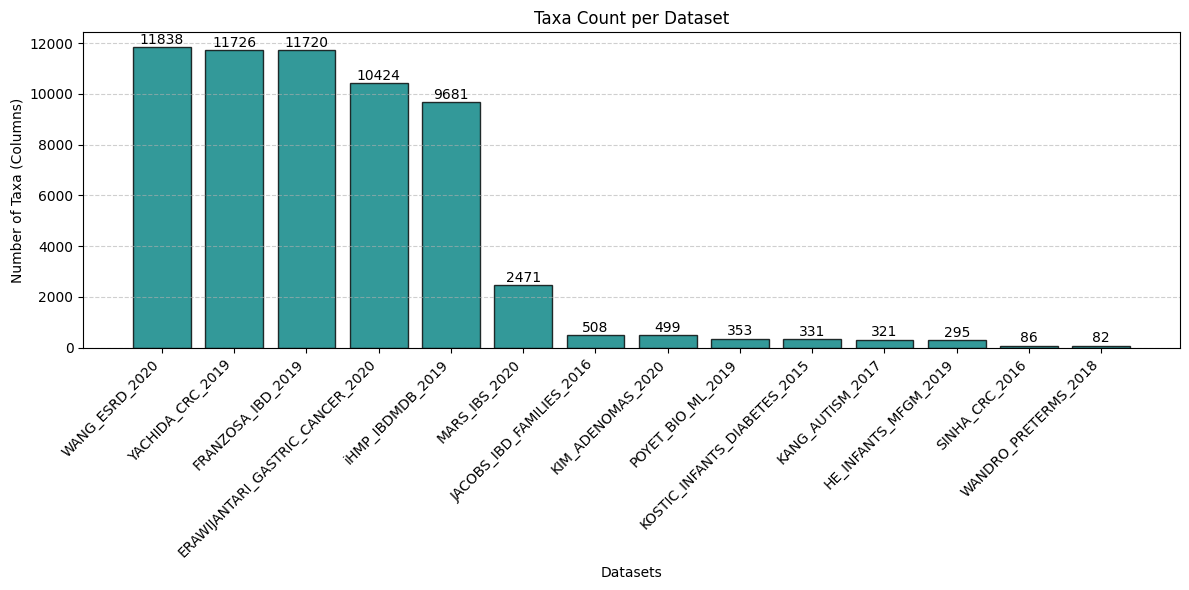

In [5]:
# 1. Put your dataframes in a list
# dfs = [df1, df2, df3, ..., df14]
df_names = [name for name in dfs_with_names.keys()]  # Create names like DF1, DF2, ..., DF14

# 2. Calculate the number of taxonomic columns for each 
# (subtracting 1 to exclude the 'Sample' ID column)
column_counts = [len(df.columns) - 1 for df in dfs_with_names.values()]

# 3. Combine and sort (optional but recommended for better visualization)
data = sorted(zip(df_names, column_counts), key=lambda x: x[1], reverse=True)
sorted_names, sorted_values = zip(*data)

# 4. Create the Bar Plot
plt.figure(figsize=(12, 6))
bars = plt.bar(sorted_names, sorted_values, color='teal', edgecolor='black', alpha=0.8)

plt.xticks(rotation=45, ha='right')  # rotate labels

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, yval,
             ha='center', va='bottom', fontsize=10)

plt.xlabel('Datasets')
plt.ylabel('Number of Taxa (Columns)')
plt.title('Taxa Count per Dataset')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### The Full Taxonomic Hierarchy
Bacteria are classified using a "coarse-to-fine" approach. In the gut microbiome datasets you are referencing, you will often find data summarized at these levels:

* **Phylum**: The broadest relevant category. In the human gut, a few phyla dominate, such as **Firmicutes**, **Bacteroidetes**, **Actinobacteria**, and **Proteobacteria**.
* **Class**: A subdivision of phylum (e.g., *Clostridia* within Firmicutes).
* **Order**: A subdivision of class (e.g., *Bacteroidales*).
* **Family**: This level is often used to group bacteria with similar functional roles, such as **Prevotellaceae** or **Porphyromonaceae**.
* **Genus**: The level you mentioned, grouping closely related species.

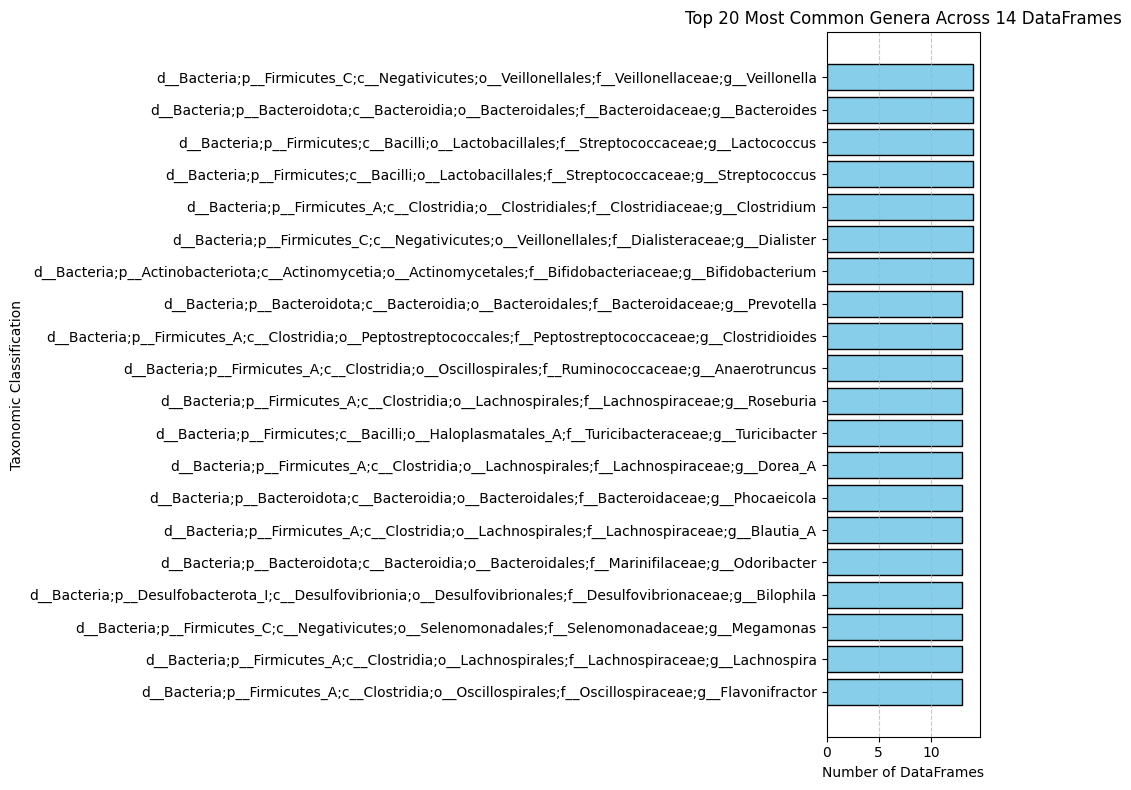

In [6]:
# 2. Extract column names (excluding 'Sample') from every DF
all_columns = []
for df in dfs_with_names.values():
    # We use set() to ensure we don't count the same column twice 
    # if it somehow appears twice in one dataframe
    cols = [c for c in df.columns if c != 'Sample']
    all_columns.extend(list(set(cols)))

# 3. Count occurrences across the 14 DataFrames
counts = Counter(all_columns)

# 4. Get the Top 20 most common for the ranking
most_common = counts.most_common(20)
names, values = zip(*most_common)

# 5. Plotting
plt.figure(figsize=(10, 8))
plt.barh(names, values, color='skyblue', edgecolor='black')
plt.xlabel('Number of DataFrames')
plt.ylabel('Taxonomic Classification')
plt.title('Top 20 Most Common Genera Across 14 DataFrames')
plt.gca().invert_yaxis()  # Put the highest count at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

In [8]:
df_names

['FRANZOSA_IBD_2019',
 'WANG_ESRD_2020',
 'KIM_ADENOMAS_2020',
 'MARS_IBS_2020',
 'POYET_BIO_ML_2019',
 'KANG_AUTISM_2017',
 'YACHIDA_CRC_2019',
 'JACOBS_IBD_FAMILIES_2016',
 'KOSTIC_INFANTS_DIABETES_2015',
 'WANDRO_PRETERMS_2018',
 'ERAWIJANTARI_GASTRIC_CANCER_2020',
 'SINHA_CRC_2016',
 'iHMP_IBDMDB_2019',
 'HE_INFANTS_MFGM_2019']

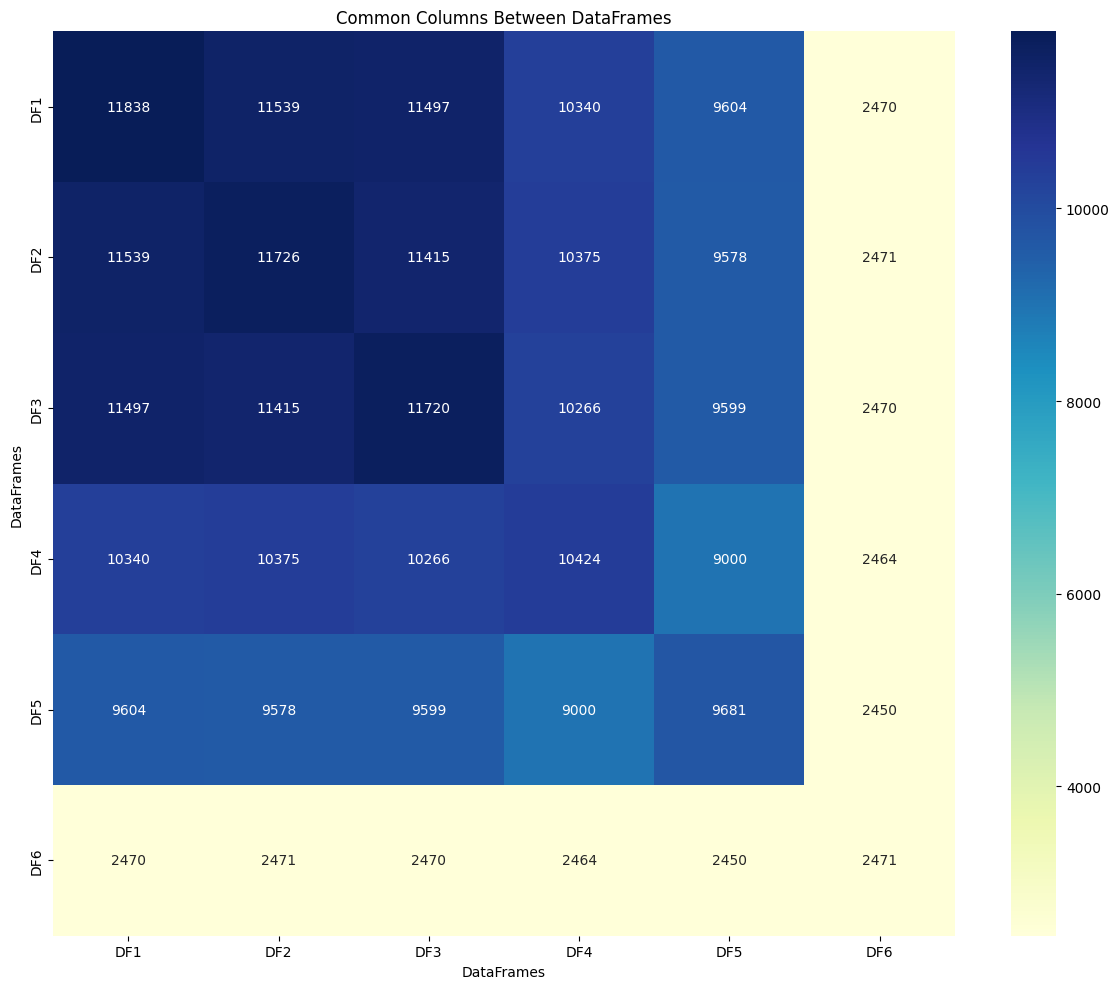

In [9]:
# 1. Store your 14 dataframes in a list
# dfs = [df1, df2, df3, ..., df14]

# 2. Extract column sets (excluding 'Sample') for each DF
# If you want to count Genera specifically, we strip the string to the 'g__' part

dfs_with_most_genera = [
    dfs_with_names['WANG_ESRD_2020'], 
    dfs_with_names['YACHIDA_CRC_2019'], 
    dfs_with_names['FRANZOSA_IBD_2019'], 
    dfs_with_names['ERAWIJANTARI_GASTRIC_CANCER_2020'], 
    dfs_with_names['iHMP_IBDMDB_2019'], 
    dfs_with_names['MARS_IBS_2020']
]

col_sets = []
for df in dfs_with_most_genera:
    # Option A: Full Taxonomic String
    cols = set(c for c in df.columns if c != 'Sample')
    # Option B: Genera only (uncomment below to use)
    # cols = set(c.split(';')[-1] for c in df.columns if 'g__' in c)
    
    col_sets.append(cols)

# 3. Create a 14x14 matrix of zeros
n = len(col_sets)
matrix = np.zeros((n, n), dtype=int)
df_names = [f"DF{i+1}" for i in range(n)]

# 4. Fill the matrix with intersection counts
for i in range(n):
    for j in range(n):
        common_count = len(col_sets[i].intersection(col_sets[j]))
        matrix[i, j] = common_count

# 5. Convert to a DataFrame for the table view
intersection_df = pd.DataFrame(matrix, index=df_names, columns=df_names)

# 6. Visualize as a Heatmap (easier to read than a raw table for 14x14)
plt.figure(figsize=(12, 10))
sns.heatmap(intersection_df, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Common Columns Between DataFrames")
plt.xlabel("DataFrames")
plt.ylabel("DataFrames")
plt.tight_layout()

plt.savefig('common_columns_matrix.png')

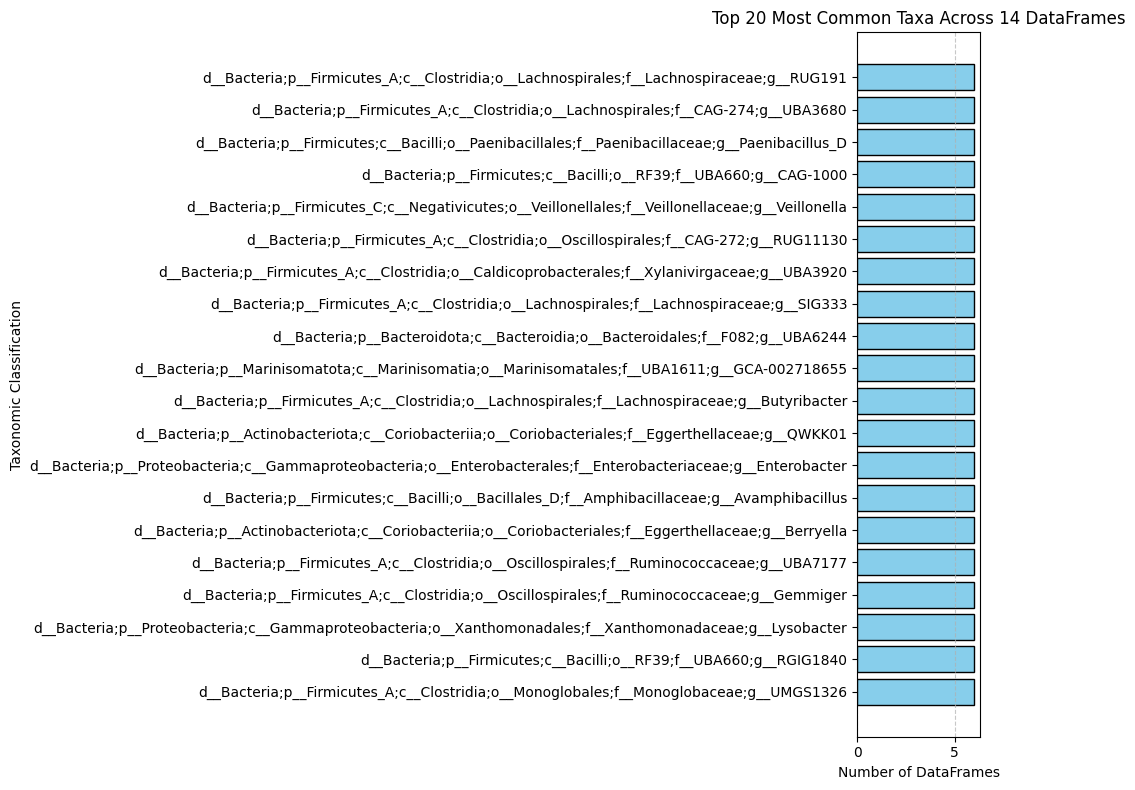

In [10]:
cols = []
all_columns = []
for df in dfs_with_most_genera:
    # We use set() to ensure we don't count the same column twice 
    # if it somehow appears twice in one dataframe
    cols = [c for c in df.columns if c != 'Sample']
    all_columns.extend(list(set(cols)))

# 3. Count occurrences across the 14 DataFrames
counts = Counter(all_columns)

# 4. Get the Top 20 most common for the ranking
most_common = counts.most_common(20)
names, values = zip(*most_common)

# 5. Plotting
plt.figure(figsize=(10, 8))
plt.barh(names, values, color='skyblue', edgecolor='black')
plt.xlabel('Number of DataFrames')
plt.ylabel('Taxonomic Classification')
plt.title('Top 20 Most Common Taxa Across 14 DataFrames')
plt.gca().invert_yaxis()  # Put the highest count at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

In [11]:
counts

Counter({'d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__RUG191': 6,
         'd__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__CAG-274;g__UBA3680': 6,
         'd__Bacteria;p__Firmicutes;c__Bacilli;o__Paenibacillales;f__Paenibacillaceae;g__Paenibacillus_D': 6,
         'd__Bacteria;p__Firmicutes;c__Bacilli;o__RF39;f__UBA660;g__CAG-1000': 6,
         'd__Bacteria;p__Firmicutes_C;c__Negativicutes;o__Veillonellales;f__Veillonellaceae;g__Veillonella': 6,
         'd__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__CAG-272;g__RUG11130': 6,
         'd__Bacteria;p__Firmicutes_A;c__Clostridia;o__Caldicoprobacterales;f__Xylanivirgaceae;g__UBA3920': 6,
         'd__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__SIG333': 6,
         'd__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__F082;g__UBA6244': 6,
         'd__Bacteria;p__Marinisomatota;c__Marinisomatia;o__Marinisomatales;f__UBA1611;

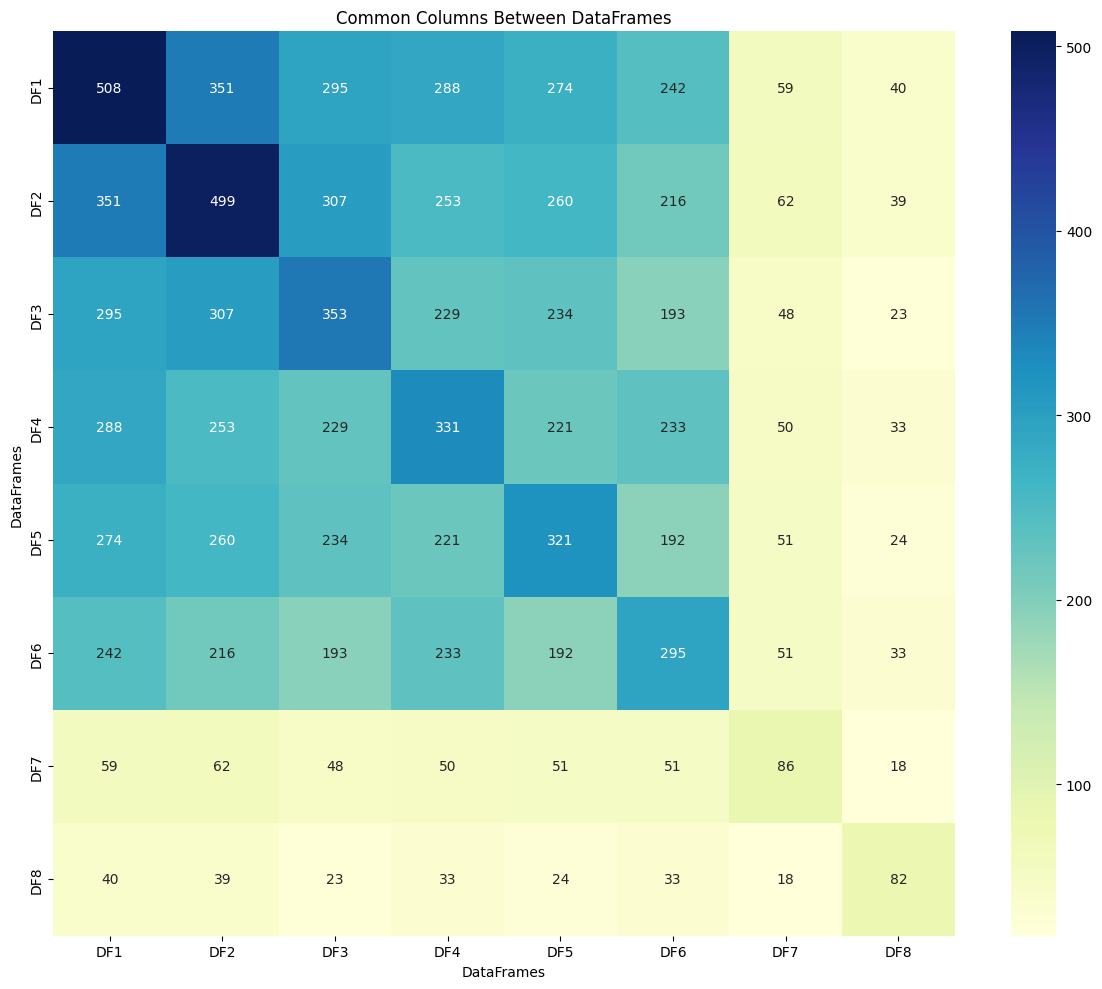

In [12]:
dfs_with_a_few_genera = [
    dfs_with_names['JACOBS_IBD_FAMILIES_2016'], 
    dfs_with_names['KIM_ADENOMAS_2020'], 
    dfs_with_names['POYET_BIO_ML_2019'], 
    dfs_with_names['KOSTIC_INFANTS_DIABETES_2015'], 
    dfs_with_names['KANG_AUTISM_2017'], 
    dfs_with_names['HE_INFANTS_MFGM_2019'], 
    dfs_with_names['SINHA_CRC_2016'], 
    dfs_with_names['WANDRO_PRETERMS_2018']
]

col_sets = []
for df in dfs_with_a_few_genera:
    # Option A: Full Taxonomic String
    cols = set(c for c in df.columns if c != 'Sample')
    
    # Option B: Genera only (uncomment below to use)
    # cols = set(c.split(';')[-1] for c in df.columns if 'g__' in c)
    
    col_sets.append(cols)

# 3. Create a 14x14 matrix of zeros
n = len(col_sets)
matrix = np.zeros((n, n), dtype=int)
df_names = [f"DF{i+1}" for i in range(n)]

# 4. Fill the matrix with intersection counts
for i in range(n):
    for j in range(n):
        common_count = len(col_sets[i].intersection(col_sets[j]))
        matrix[i, j] = common_count

# 5. Convert to a DataFrame for the table view
intersection_df = pd.DataFrame(matrix, index=df_names, columns=df_names)

# 6. Visualize as a Heatmap (easier to read than a raw table for 14x14)
plt.figure(figsize=(12, 10))
sns.heatmap(intersection_df, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Common Columns Between DataFrames")
plt.xlabel("DataFrames")
plt.ylabel("DataFrames")
plt.tight_layout()

plt.savefig('common_columns_matrix.png')

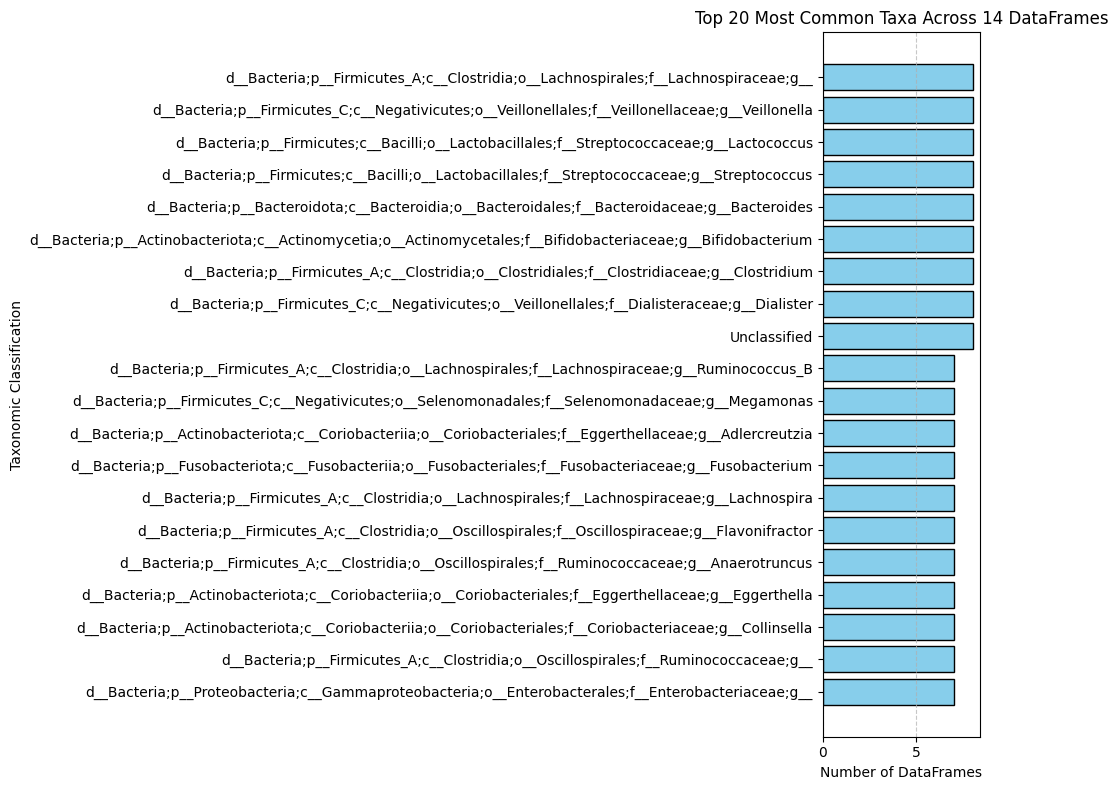

In [13]:
cols = []
all_columns = []
for df in dfs_with_a_few_genera:
    # We use set() to ensure we don't count the same column twice 
    # if it somehow appears twice in one dataframe
    cols = [c for c in df.columns if c != 'Sample']
    all_columns.extend(list(set(cols)))

# 3. Count occurrences across the 14 DataFrames
counts = Counter(all_columns)

# 4. Get the Top 20 most common for the ranking
most_common = counts.most_common(20)
names, values = zip(*most_common)

# 5. Plotting
plt.figure(figsize=(10, 8))
plt.barh(names, values, color='skyblue', edgecolor='black')
plt.xlabel('Number of DataFrames')
plt.ylabel('Taxonomic Classification')
plt.title('Top 20 Most Common Taxa Across 14 DataFrames')
plt.gca().invert_yaxis()  # Put the highest count at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

- d__	Domain	Bacteria	The highest level; distinguishes bacteria from archaea or eukaryotes.
- p__	Phylum	Firmicutes	One of the most abundant phyla in the human gut.
- c__	Class	Bacilli	A large group of diverse bacteria.
- o__	Order	Lactobacillales	Often referred to as "Lactic Acid Bacteria."
- f__	Family	Streptococcaceae	Groups together genera like Streptococcus and Lactococcus.
- g__	Genus	Lactococcus	The specific group this bacterium belongs to.

In [ ]:
counts

Counter({'d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Streptococcaceae;g__Lactococcus': 14,
         'd__Bacteria;p__Firmicutes_A;c__Clostridia;o__Clostridiales;f__Clostridiaceae;g__Clostridium': 14,
         'd__Bacteria;p__Firmicutes_C;c__Negativicutes;o__Veillonellales;f__Veillonellaceae;g__Veillonella': 14,
         'd__Bacteria;p__Firmicutes_C;c__Negativicutes;o__Veillonellales;f__Dialisteraceae;g__Dialister': 14,
         'd__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Streptococcaceae;g__Streptococcus': 14,
         'd__Bacteria;p__Actinobacteriota;c__Actinomycetia;o__Actinomycetales;f__Bifidobacteriaceae;g__Bifidobacterium': 14,
         'd__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides': 14,
         'd__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Enterobacterales;f__Pasteurellaceae;g__Haemophilus_D': 13,
         'd__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Bl

# Longitudinal

In [ ]:

df_metadata_longitudinal = pd.read_csv('processed_data/HE_INFANTS_MFGM_2019/metadata.tsv', sep = '\t')

In [ ]:
df_metadata_longitudinal.info()

<class 'pandas.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Dataset           277 non-null    str  
 1   Sample            277 non-null    str  
 2   Subject           277 non-null    str  
 3   Study.Group       277 non-null    str  
 4   Age               277 non-null    int64
 5   Age.Units         277 non-null    str  
 6   Gender            277 non-null    str  
 7   DOI               277 non-null    str  
 8   Publication.Name  277 non-null    str  
 9   BarcodeSequence   277 non-null    str  
 10  diet              277 non-null    str  
 11  Description       277 non-null    str  
dtypes: int64(1), str(11)
memory usage: 26.1 KB


In [ ]:
df_metadata_longitudinal

,Dataset,Sample,Subject,Study.Group,Age,Age.Units,Gender,DOI,Publication.Name,BarcodeSequence,diet,Description
0,HE_INFANTS_MFGM_2019,BF.13.1,BF13,Baseline,2,Months,Female,10.1038/s41598-019-47953-4,Fecal microbiome and metabolome of infants fed...,ACACCTGA,Breast milk,BF_0
1,HE_INFANTS_MFGM_2019,BF.13.2,BF13,Without.comp.food,4,Months,Female,10.1038/s41598-019-47953-4,Fecal microbiome and metabolome of infants fed...,ACTCAGAC,Breast milk,BF_4
2,HE_INFANTS_MFGM_2019,BF.13.3,BF13,Without.comp.food,6,Months,Female,10.1038/s41598-019-47953-4,Fecal microbiome and metabolome of infants fed...,AGCTTCGA,Breast milk,BF_6
3,HE_INFANTS_MFGM_2019,BF.13.4,BF13,Month12,12,Months,Female,10.1038/s41598-019-47953-4,Fecal microbiome and metabolome of infants fed...,AACCGCTA,Breast milk,BF_12
4,HE_INFANTS_MFGM_2019,BF.14.1,BF14,Baseline,2,Months,Female,10.1038/s41598-019-47953-4,Fecal microbiome and metabolome of infants fed...,ACACGTGT,Breast milk,BF_0
...,...,...,...,...,...,...,...,...,...,...,...,...
272,HE_INFANTS_MFGM_2019,EP.77.2,EP77,Without.comp.food,4,Months,Male,10.1038/s41598-019-47953-4,Fecal microbiome and metabolome of infants fed...,AGAGCTGA,Experimental infant formula,EF_4
273,HE_INFANTS_MFGM_2019,EP.77.3,EP77,With.comp.food,6,Months,Male,10.1038/s41598-019-47953-4,Fecal microbiome and metabolome of infants fed...,AGTGCACT,Experimental infant formula,EF_6
274,HE_INFANTS_MFGM_2019,EP.9.1,EP9,Baseline,2,Months,Male,10.1038/s41598-019-47953-4,Fecal microbiome and metabolome of infants fed...,AAGCTTGC,Experimental infant formula,EF_0
275,HE_INFANTS_MFGM_2019,EP.9.2,EP9,Without.comp.food,4,Months,Male,10.1038/s41598-019-47953-4,Fecal microbiome and metabolome of infants fed...,ACGAGAAC,Experimental infant formula,EF_4


In [ ]:
df_metadata_longitudinal.query("Subject == 'BF13'")

,Dataset,Sample,Subject,Study.Group,Age,Age.Units,Gender,DOI,Publication.Name,BarcodeSequence,diet,Description
0,HE_INFANTS_MFGM_2019,BF.13.1,BF13,Baseline,2,Months,Female,10.1038/s41598-019-47953-4,Fecal microbiome and metabolome of infants fed...,ACACCTGA,Breast milk,BF_0
1,HE_INFANTS_MFGM_2019,BF.13.2,BF13,Without.comp.food,4,Months,Female,10.1038/s41598-019-47953-4,Fecal microbiome and metabolome of infants fed...,ACTCAGAC,Breast milk,BF_4
2,HE_INFANTS_MFGM_2019,BF.13.3,BF13,Without.comp.food,6,Months,Female,10.1038/s41598-019-47953-4,Fecal microbiome and metabolome of infants fed...,AGCTTCGA,Breast milk,BF_6
3,HE_INFANTS_MFGM_2019,BF.13.4,BF13,Month12,12,Months,Female,10.1038/s41598-019-47953-4,Fecal microbiome and metabolome of infants fed...,AACCGCTA,Breast milk,BF_12


In [ ]:
df_metadata_longitudinal.describe()

,Age
count,277.000000
mean,6.014440
std,3.706605
min,2.000000
25%,4.000000
50%,6.000000
75%,6.000000
max,12.000000


In [ ]:
children = [value[0] for value in list(df_metadata_longitudinal[['Subject']].values)]

In [ ]:
len(set(children))

80

In [ ]:
children_count = Counter(children)

In [ ]:
children_count

Counter({'BF13': 4,
         'BF14': 4,
         'BF31': 4,
         'BF7': 4,
         'BP13': 4,
         'BP22': 4,
         'BP30': 4,
         'BP39': 4,
         'BP8': 4,
         'EF1': 4,
         'EF12': 4,
         'EF13': 4,
         'EF18': 4,
         'EF3': 4,
         'EF33': 4,
         'EF34': 4,
         'EF41': 4,
         'EF43': 4,
         'EF46': 4,
         'EF47': 4,
         'EF48': 4,
         'EF54': 4,
         'EF55': 4,
         'EF56': 4,
         'EF63': 4,
         'EF66': 4,
         'EF7': 4,
         'EF70': 4,
         'EF72': 4,
         'EF75': 4,
         'EP11': 4,
         'EP12': 4,
         'EP14': 4,
         'EP21': 4,
         'EP23': 4,
         'EP25': 4,
         'EP27': 4,
         'EP29': 4,
         'EP33': 4,
         'EP39': 4,
         'EP44': 4,
         'EP45': 4,
         'EP49': 4,
         'EP54': 4,
         'EP57': 4,
         'EP58': 4,
         'EP60': 4,
         'EP64': 4,
         'EP66': 4,
         'EP70': 4,
     

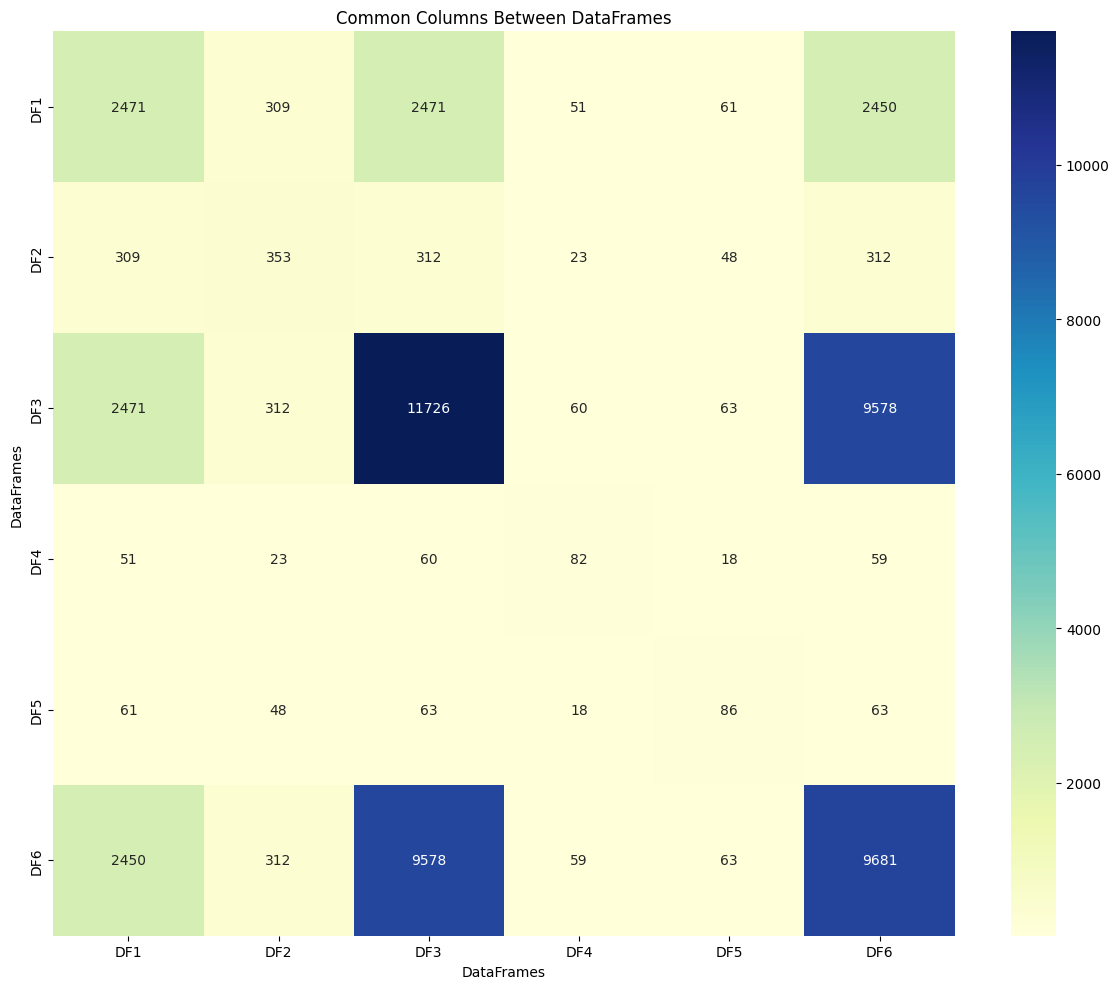

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Store your 14 dataframes in a list
# dfs = [df1, df2, df3, ..., df14]

# 2. Extract column sets (excluding 'Sample') for each DF
# If you want to count Genera specifically, we strip the string to the 'g__' part

dfs_with_most_genera = [dfs[3], dfs[4], dfs[6], dfs[9], dfs[11], dfs[12]]

col_sets = []
for df in dfs_with_most_genera:
    # Option A: Full Taxonomic String
    cols = set(c for c in df.columns if c != 'Sample')
    
    # Option B: Genera only (uncomment below to use)
    # cols = set(c.split(';')[-1] for c in df.columns if 'g__' in c)
    
    col_sets.append(cols)

# 3. Create a 14x14 matrix of zeros
n = len(col_sets)
matrix = np.zeros((n, n), dtype=int)
df_names = [f"DF{i+1}" for i in range(n)]

# 4. Fill the matrix with intersection counts
for i in range(n):
    for j in range(n):
        common_count = len(col_sets[i].intersection(col_sets[j]))
        matrix[i, j] = common_count

# 5. Convert to a DataFrame for the table view
intersection_df = pd.DataFrame(matrix, index=df_names, columns=df_names)

# 6. Visualize as a Heatmap (easier to read than a raw table for 14x14)
plt.figure(figsize=(12, 10))
sns.heatmap(intersection_df, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Common Columns Between DataFrames")
plt.xlabel("DataFrames")
plt.ylabel("DataFrames")
plt.tight_layout()

plt.savefig('common_columns_matrix.png')

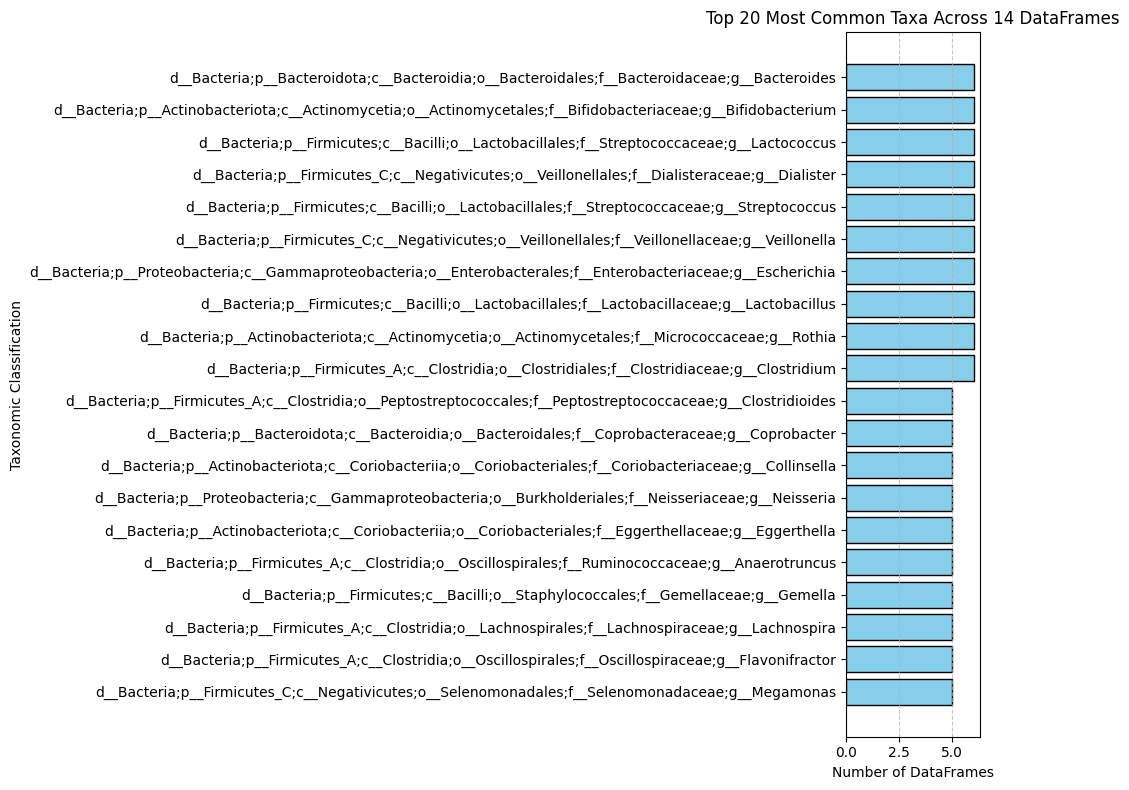

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter


# 2. Extract column names (excluding 'Sample') from every DF
dfs_with_most_genera = [dfs[3], dfs[4], dfs[6], dfs[9], dfs[11], dfs[12]]
cols = []
all_columns = []
for df in dfs_with_most_genera:
    # We use set() to ensure we don't count the same column twice 
    # if it somehow appears twice in one dataframe
    cols = [c for c in df.columns if c != 'Sample']
    all_columns.extend(list(set(cols)))

# 3. Count occurrences across the 14 DataFrames
counts = Counter(all_columns)

# 4. Get the Top 20 most common for the ranking
most_common = counts.most_common(20)
names, values = zip(*most_common)

# 5. Plotting
plt.figure(figsize=(10, 8))
plt.barh(names, values, color='skyblue', edgecolor='black')
plt.xlabel('Number of DataFrames')
plt.ylabel('Taxonomic Classification')
plt.title('Top 20 Most Common Taxa Across 14 DataFrames')
plt.gca().invert_yaxis()  # Put the highest count at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

In [ ]:
dfs_with_most_genera_2 = [dfs[1], dfs[6], dfs[0], dfs[10], dfs[12], dfs[3]]

In [ ]:
dfs_with_most_genera_2 = [dfs[1], dfs[6], dfs[0], dfs[10], dfs[12], dfs[3]]

# Obtener columnas comunes usando sets
common_cols = set.intersection(*(set(df.columns) for df in dfs_with_most_genera_2))

# Filtrar cada dataframe con esas columnas
filtered_dfs = [df[list(common_cols)] for df in dfs_with_most_genera_2]

In [ ]:
len(list(common_cols))

2444

In [ ]:
from pathlib import Path

# 1. Define la ruta de la carpeta principal
ruta_base = Path('./processed_data')

# 2. Busca todos los archivos 'genera.tsv' en las subcarpetas
# rglob busca de forma recursiva (en todas las carpetas hijo)
archivos_tsv = ruta_base.rglob('mtb.tsv')

# 3. Leer y combinar (opcional)
lista_dataframes = []

dfs = []

for ruta in archivos_tsv:
    print(f"Leyendo: {ruta}")
    # Leemos con sep='\t' porque es un TSV (Tab Separated Values)
    df = pd.read_csv(ruta, sep='\t')
    print(f"Dimensiones antes de limpiar: {df.shape}")
    df = df.loc[:, (df != 0).any(axis=0)] # remove columns where all values are 0
    print(f"Dimensiones después de limpiar: {df.shape}")
    dfs.append(df)



Leyendo: processed_data/FRANZOSA_IBD_2019/mtb.tsv
Dimensiones antes de limpiar: (220, 8849)
Dimensiones después de limpiar: (220, 8849)
Leyendo: processed_data/WANG_ESRD_2020/mtb.tsv
Dimensiones antes de limpiar: (287, 277)
Dimensiones después de limpiar: (287, 277)
Leyendo: processed_data/KIM_ADENOMAS_2020/mtb.tsv
Dimensiones antes de limpiar: (240, 463)
Dimensiones después de limpiar: (240, 463)
Leyendo: processed_data/MARS_IBS_2020/mtb.tsv
Dimensiones antes de limpiar: (444, 44)
Dimensiones después de limpiar: (444, 44)
Leyendo: processed_data/POYET_BIO_ML_2019/mtb.tsv
Dimensiones antes de limpiar: (164, 490)
Dimensiones después de limpiar: (164, 490)
Leyendo: processed_data/KANG_AUTISM_2017/mtb.tsv
Dimensiones antes de limpiar: (44, 62)
Dimensiones después de limpiar: (44, 60)
Leyendo: processed_data/YACHIDA_CRC_2019/mtb.tsv
Dimensiones antes de limpiar: (347, 451)
Dimensiones después de limpiar: (347, 447)
Leyendo: processed_data/JACOBS_IBD_FAMILIES_2016/mtb.tsv
Dimensiones antes 

In [ ]:
len(dfs)

13

In [ ]:
dfs_with_most_genera_2 = [dfs[1], dfs[6], dfs[0], dfs[10], dfs[12], dfs[3]]

# Obtener columnas comunes usando sets
common_cols = set.intersection(*(set(df.columns) for df in dfs_with_most_genera_2))

# Filtrar cada dataframe con esas columnas
filtered_dfs = [df[list(common_cols)] for df in dfs_with_most_genera_2]

In [ ]:
len(list(common_cols))

1

In [ ]:
list(common_cols)

['Sample']

In [ ]:
common_cols = set.intersection(*(set(df.columns) for df in [df_mtb, df_mtb_2]))

In [ ]:
common_cols

{'Sample'}

In [ ]:
df_mtb

,Sample,-_2-Hydroxyisobutyrate,-_2-Hydroxyoctanoate,-_2-Hydroxypentanoate,-_2-Oxooctanoate,-_3-Indoxyl sulfate,-_4-Oxohexanoate,-_4-Oxopentanoate,-_Cysteine-glutathione disulphide,-_Cysteine-glutathione disulphide -Divalent,...,C11284_3-Indolebutyrate,C11331_Leu-Leu-Tyr,C11527_4-Hydroxymandelate,C15587_Purine,C16741_5-Hydroxylysine,C17714_Heptanoate,C17715_Undecanoate,_3-Aminopyrrolidine,_Diazoxide,_Diethyl-2-phenylacetamide
0,10776.Healthy,0.000000,0.000000,544.606822,0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.0,48.262346,0.000000,0.0,0,123.440237,0
1,10850.Healthy,0.000000,0.000000,574.111341,0,0.0,0.0,0.0,0.0,2.776857,...,0.000000,6.161976,0.000000,0.0,368.661127,0.000000,0.0,0,122.646971,0
2,10543.Healthy,0.000000,0.000000,0.000000,0,0.0,0.0,0.0,0.0,0.000000,...,60.089022,0.000000,62.652325,0.0,109.446543,0.000000,0.0,0,0.000000,0
3,10246.Healthy,0.000000,0.000000,464.163389,0,0.0,0.0,0.0,0.0,2.806007,...,0.000000,0.000000,0.000000,0.0,916.588182,0.000000,0.0,0,118.245341,0
4,10156.Gastrectomy,0.000000,0.000000,0.000000,0,0.0,0.0,0.0,7.7,0.000000,...,0.000000,0.000000,0.000000,0.0,27.000000,0.000000,0.0,0,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,10782.Gastrectomy,0.000000,0.000000,0.000000,0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.0,51.000000,0.000000,0.0,0,0.000000,0
92,10340.Healthy,0.000000,127.753466,0.000000,0,0.0,0.0,0.0,0.0,9.364460,...,0.000000,0.000000,0.000000,0.0,144.584487,0.000000,0.0,0,0.000000,0
93,10189.Gastrectomy,0.000000,0.000000,0.000000,0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.0,31.253750,527.965033,0.0,0,113.111546,0
94,10226.Healthy,187.224104,0.000000,0.000000,0,0.0,0.0,0.0,0.0,0.000000,...,2450.367798,0.000000,233.665444,0.0,35.952032,406.495107,0.0,0,0.000000,0


In [ ]:
df_mtb.describe()

,-_2-Hydroxyisobutyrate,-_2-Hydroxyoctanoate,-_2-Hydroxypentanoate,-_2-Oxooctanoate,-_3-Indoxyl sulfate,-_4-Oxohexanoate,-_4-Oxopentanoate,-_Cysteine-glutathione disulphide,-_Cysteine-glutathione disulphide -Divalent,-_N-Acetylvaline,...,C11284_3-Indolebutyrate,C11331_Leu-Leu-Tyr,C11527_4-Hydroxymandelate,C15587_Purine,C16741_5-Hydroxylysine,C17714_Heptanoate,C17715_Undecanoate,_3-Aminopyrrolidine,_Diazoxide,_Diethyl-2-phenylacetamide
count,96.000000,96.000000,96.000000,96.0,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,...,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.0,96.000000,96.0
mean,49.975585,122.197262,166.078052,0.0,26.962916,0.330567,5.281179,2.048958,1.217759,37.654850,...,465.741164,0.417060,132.120894,0.502083,205.126090,67.562916,0.675152,0.0,16.604301,0.0
std,252.693906,422.684549,381.821230,0.0,158.091399,3.238881,29.269355,8.357058,6.469686,84.257559,...,1378.448459,1.884668,461.774571,3.126524,420.095659,187.090382,2.923096,0.0,40.481627,0.0
min,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0
25%,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,17.958039,0.000000,0.000000,0.0,0.000000,0.0
50%,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,13.684289,...,0.000000,0.000000,0.000000,0.000000,35.976016,0.000000,0.000000,0.0,0.000000,0.0
75%,0.000000,9.778226,151.755396,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,38.097876,...,149.715594,0.000000,0.000000,0.000000,164.404211,0.000000,0.000000,0.0,0.000000,0.0
max,2361.245804,3202.598987,2108.900658,0.0,1462.000000,31.734421,235.668432,51.000000,59.388071,584.000000,...,9223.694443,12.638871,4010.766271,26.000000,2815.057950,1070.746436,14.648668,0.0,123.440237,0.0


In [ ]:
df_mtb_2

,Sample,_1_11_UNDECANEDICARBOXYLATE,_1_2_PROPANEDIOL,_1_3_7_TRIMETHYLURATE,_1_HEXADECANOL,_1_METHYLXANTHINE,_1_OCTADECANOL,_1_OLEOYLGLYCEROPHOSPHOCHOLIN,_1_OLEOYLGLYCEROPHOSPHOETHANO,_1_PALMITOYLGLYCEROL,...,X_18165,X_18167,X_18599,X_18774,X_19126,X_19133,X_19140,X_19232,X_19496,X_19572
0,CRC.222,-0.154551,-0.424801,-0.069886,-1.199981,0.363184,-1.174738,1.467275,0.496950,0.608624,...,1.309845,1.610437,-0.061450,0.988165,3.174439,0.395819,4.910535,0.089566,0.160672,0.044113
1,CRC.57,0.079920,0.016070,1.465383,1.182616,-1.533867,0.707888,0.174877,1.469394,-0.167354,...,-0.171500,0.610200,2.188206,1.477414,0.202124,-0.225396,1.816989,0.262133,0.783308,1.311301
2,CRC.82,1.538157,0.455778,-3.611918,-0.391710,-0.359536,-0.907827,2.168036,-0.102143,1.390660,...,-0.060600,-0.459024,0.306013,0.962220,-0.501701,-1.406497,4.680489,-0.916041,3.341745,4.667663
3,CRC.220,0.634988,0.218734,-0.133646,1.383841,1.975927,1.072405,-0.648748,-0.377023,-0.453029,...,0.025863,1.073021,-0.389198,0.040374,-0.224019,0.000000,0.171934,0.232301,-0.530008,0.232698
4,CRC.90,-0.297194,-0.557568,-0.161696,0.782531,0.870456,0.114310,-1.443923,-0.852847,-0.097503,...,-1.830708,1.096176,0.544937,-0.280773,0.378573,1.160710,3.016941,0.081764,-0.672756,-0.049716
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,CRC.196,-1.533403,-0.119798,-1.575520,0.595479,1.625233,0.027031,-1.525556,0.416141,-0.211956,...,0.656691,0.759029,2.508607,0.119027,0.739028,-2.093135,-0.645882,1.016715,-0.661261,-0.210844
127,CRC.19,0.205305,-0.393191,0.118139,-1.624552,1.672863,-1.295357,0.906160,-0.132275,0.854203,...,-0.302457,-0.127493,-0.338274,1.339910,-0.158175,-1.008954,-1.092133,0.261595,-0.294774,-0.104583
128,CRC.194,-1.384696,-0.989668,1.777762,-0.929883,-0.064005,-1.212677,2.815894,0.807145,-0.510159,...,-0.731888,-1.610939,-2.469821,-3.034473,1.400025,-0.480943,2.803797,-0.933691,-0.815315,-0.362693
129,CRC.177,0.126985,-0.111267,1.815395,1.428060,-2.916921,0.974861,-1.904480,-1.009778,-0.767440,...,-1.102018,-1.342852,0.642117,0.280657,0.495001,-1.438430,5.465918,-0.972861,-0.393191,-0.243219


In [ ]:
df_mtb_3 = pd.read_csv('processed_data/WANG_ESRD_2020/mtb.tsv', sep = '\t')

In [ ]:
df_mtb_3

,Sample,"Cyclotrisiloxane, hexamethyl-",Benzaldehyde,"Cyclopentasiloxane, decamethyl-",Styrene,Phenol,n-Pentadecanol,Toluene,Indole,Carbon dioxide,...,"Decane, 2,2,3-trimethyl-",cis-11-Hexadecenal,"1,1-Dichloropentane","1,4-p-Menthadien-7-al","Cyclopentanecarboxylic acid, 4-nitrophenyl ester",Isobutyl isovalerate,251_unknown,"Cyclohexanone, 2,2,6-trimethyl-",1-Decanol,Methyl tetradecanoate
0,CON-001,0.011931,0.087967,0.051197,0.172107,0.049930,0.005340,0.113204,0.642949,0.031697,...,5.236453e-02,8.051328e-09,8.606949e-03,8.051328e-09,1.798532e-02,9.874148e-07,1.363812e-03,8.051328e-09,8.051328e-09,1.429219e-03
1,CON-002,0.069543,0.359398,0.191413,0.725868,0.167047,0.101231,0.579727,27.893334,0.063823,...,9.243080e-03,8.066107e-09,4.593440e-03,8.066107e-09,8.066107e-09,3.237582e-03,7.015772e-03,8.689936e-03,8.066107e-09,6.598504e-02
2,CON-003,0.064806,0.371002,0.192658,0.612681,0.093682,0.129043,1.222348,9.929321,0.174733,...,1.559581e-08,5.577590e-02,2.996485e-02,5.102441e-02,1.559581e-08,1.559581e-08,6.265439e-03,1.559581e-08,2.388436e-01,1.559581e-08
3,CON-004,0.024174,0.779997,0.144118,0.925795,0.016245,0.593587,0.927712,12.856515,0.061969,...,1.805360e-02,7.523501e-09,7.523501e-09,7.523501e-09,7.523501e-09,9.783985e-04,4.596547e-03,7.523501e-09,1.167647e-02,5.101213e-02
4,CON-005,0.019268,0.127031,0.092488,0.584368,0.012674,0.775437,0.324421,4.813590,0.009148,...,7.652018e-09,7.652018e-09,7.182517e-04,7.652018e-09,7.652018e-09,7.652018e-09,1.418566e-03,7.652018e-09,7.652018e-09,4.971664e-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
282,KD-219,0.043281,0.399107,0.188049,1.654339,3.581015,1.310288,0.285898,31.696957,0.253835,...,7.768872e-02,8.814835e-03,1.919101e-08,1.919101e-08,1.919101e-08,5.320631e-03,3.461297e-03,1.811109e-02,1.740265e-02,1.150905e-02
283,KD-220,0.014782,1.349298,0.070555,0.310908,1.588726,0.455715,0.287722,22.697519,0.015670,...,5.051199e-02,9.412195e-04,2.911273e-03,1.043946e-08,1.429298e-03,1.043946e-08,1.723631e-03,1.028234e-03,4.430921e-03,6.294021e-02
284,KD-221,0.019149,0.278288,0.080161,0.275156,0.428709,0.028301,0.094374,1.308955,0.090357,...,1.712191e-02,1.002137e-08,4.937165e-03,1.002137e-08,5.242574e-03,1.027191e-04,1.716353e-03,5.789263e-04,1.002137e-08,1.002137e-08
285,KD-222,0.390022,0.246633,2.645785,7.697368,66.889933,1.432668,0.841031,266.729097,1.397951,...,1.814184e-07,1.814184e-07,1.814184e-07,2.739466e-01,3.953997e-01,1.814184e-07,1.814184e-07,6.722564e-02,1.814184e-07,3.607443e-02


In [ ]:
common_cols = set.intersection(*(set(df.columns) for df in [df_mtb, df_mtb_3]))

In [ ]:
common_cols

{'Sample'}

In [ ]:
df_mtb__map_3 = pd.read_csv('processed_data/WANG_ESRD_2020/mtb.map.tsv', sep = '\t')

In [ ]:
common_cols = set.intersection(*(set(df.columns) for df in [df_mtb_map, df_mtb__map_3]))

In [ ]:
common_cols

{'Compound', 'HMDB', 'High.Confidence.Annotation', 'KEGG'}

In [ ]:
df_mtb.columns

Index(['Sample', '-_2-Hydroxyisobutyrate', '-_2-Hydroxyoctanoate',
       '-_2-Hydroxypentanoate', '-_2-Oxooctanoate', '-_3-Indoxyl sulfate',
       '-_4-Oxohexanoate', '-_4-Oxopentanoate',
       '-_Cysteine-glutathione disulphide',
       '-_Cysteine-glutathione disulphide -Divalent',
       ...
       'C11284_3-Indolebutyrate', 'C11331_Leu-Leu-Tyr',
       'C11527_4-Hydroxymandelate', 'C15587_Purine', 'C16741_5-Hydroxylysine',
       'C17714_Heptanoate', 'C17715_Undecanoate', '_3-Aminopyrrolidine',
       '_Diazoxide', '_Diethyl-2-phenylacetamide'],
      dtype='str', length=525)

In [ ]:
df_mtb_3.columns

Index(['Sample', 'Cyclotrisiloxane, hexamethyl-', 'Benzaldehyde',
       'Cyclopentasiloxane, decamethyl-', 'Styrene', 'Phenol',
       'n-Pentadecanol', 'Toluene', 'Indole', 'Carbon dioxide',
       ...
       'Decane, 2,2,3-trimethyl-', 'cis-11-Hexadecenal', '1,1-Dichloropentane',
       '1,4-p-Menthadien-7-al',
       'Cyclopentanecarboxylic acid, 4-nitrophenyl ester',
       'Isobutyl isovalerate', '251_unknown',
       'Cyclohexanone, 2,2,6-trimethyl-', '1-Decanol',
       'Methyl tetradecanoate'],
      dtype='str', length=277)

In [ ]:
df_mtb_map

,Compound,KEGG,HMDB,High.Confidence.Annotation
0,C03173_(Methylthio)acetate,C03173,HMDB0035646,True
1,C03969_1-Amino-1-cyclopentanecarboxylate,C03969,HMDB0062225,True
2,C01234_1-Aminocyclopropane-1-carboxylate,C01234,HMDB0036458,True
3,C03782_1-Aminoethylphosphonate,C03782,HMDB0247130,True
4,C11118_1-Methyl-2-pyrrolidinone,C11118,HMDB0002039,True
...,...,...,...,...
519,-_Xanthopterin,NaN,HMDB0259923,True
520,C01762_Xanthosine,C01762,HMDB0000299,True
521,C02470_Xanthurenate,C02470,HMDB0000881,True
522,C00655_XMP,C00655,HMDB0001554,True


In [ ]:
columns_df_mtb = df_mtb.columns

In [ ]:
len(columns_df_mtb)

525

In [ ]:
df_mtb_map[['Compound']]

,Compound
0,C03173_(Methylthio)acetate
1,C03969_1-Amino-1-cyclopentanecarboxylate
2,C01234_1-Aminocyclopropane-1-carboxylate
3,C03782_1-Aminoethylphosphonate
4,C11118_1-Methyl-2-pyrrolidinone
...,...
519,-_Xanthopterin
520,C01762_Xanthosine
521,C02470_Xanthurenate
522,C00655_XMP


In [153]:
compound_list = df_mtb_map['Compound'].tolist()

In [154]:
compound_list

['C03173_(Methylthio)acetate',
 'C03969_1-Amino-1-cyclopentanecarboxylate',
 'C01234_1-Aminocyclopropane-1-carboxylate',
 'C03782_1-Aminoethylphosphonate',
 'C11118_1-Methyl-2-pyrrolidinone',
 'C02494_1-Methyladenosine',
 'C05127_1-Methylhistamine',
 'C02918_1-Methylnicotinamide',
 'C00986_1,3-Diaminopropane',
 'C02774_10-Hydroxydecanoate',
 "C00881_2'-Deoxycytidine",
 "C00330_2'-Deoxyguanosine",
 "C05512_2'-Deoxyinosine",
 "C02354_2',3'-cCMP",
 'C05672_2-Amino-3-phosphonopropionate',
 'C10901_2-Aminobenzimidazole',
 'C03557_2-Aminoethylphosphonate',
 'C01987_2-Aminophenol',
 'C06369_2-Deoxyglucose 6-phosphate',
 'C00672_2-Deoxyribose 1-phosphate',
 'C02627_2-Deoxystreptamine',
 'C01546_2-Furoate',
 'C10898_2-Guanidinobenzimidazole',
 'C03264_2-Hydroxy-4-methylpentanoate',
 'C05984_2-Hydroxybutyrate',
 'C02630_2-Hydroxyglutarate',
 '-_2-Hydroxyisobutyrate',
 '-_2-Hydroxyoctanoate',
 '-_2-Hydroxypentanoate',
 'C05852_2-Hydroxyphenylacetate',
 'C02504_2-Isopropylmalate',
 'C00322_2-Oxoad

In [156]:
list(columns_df_mtb)

['Sample',
 '-_2-Hydroxyisobutyrate',
 '-_2-Hydroxyoctanoate',
 '-_2-Hydroxypentanoate',
 '-_2-Oxooctanoate',
 '-_3-Indoxyl sulfate',
 '-_4-Oxohexanoate',
 '-_4-Oxopentanoate',
 '-_Cysteine-glutathione disulphide',
 '-_Cysteine-glutathione disulphide -Divalent',
 '-_N-Acetylvaline',
 '-_N1,N8-Diacetylspermidine',
 '-_Ophthalmate',
 '-_Phe-Phe',
 '-_SDMA',
 '-_Xanthopterin',
 '-_gamma-Glu-2AB',
 '-_n-Butyl a-Picolinate',
 'C00002_ATP',
 'C00003_NAD+',
 'C00004_NADH',
 'C00005_NADPH',
 'C00006_NADP+',
 'C00008_ADP',
 'C00010_CoA',
 'C00015_UDP',
 'C00016_FAD',
 'C00019_SAM+',
 'C00020_AMP',
 'C00021_SAH',
 'C00022_Pyruvate',
 'C00024_Acetyl CoA',
 'C00025_Glu',
 'C00026_2-Oxoglutarate',
 'C00029_UDP-glucose',
 'C00035_GDP',
 'C00037_Gly',
 'C00041_Ala',
 'C00042_Succinate',
 'C00043_UDP-N-acetylglucosamine',
 'C00044_GTP',
 'C00047_Lys',
 'C00048_Glyoxylate',
 'C00049_Asp',
 'C00051_Glutathione(red)',
 "C00054_Adenosine 3',5'-diphosphate",
 'C00055_CMP',
 'C00062_Arg',
 'C00063_CTP',
 'C

In [158]:
len(set(compound_list + list(columns_df_mtb)))

525

In [159]:
compound_hmdb_dict = dict(zip(df_mtb_map['Compound'], df_mtb_map['HMDB']))

In [160]:
compound_hmdb_dict

{'C03173_(Methylthio)acetate': 'HMDB0035646',
 'C03969_1-Amino-1-cyclopentanecarboxylate': 'HMDB0062225',
 'C01234_1-Aminocyclopropane-1-carboxylate': 'HMDB0036458',
 'C03782_1-Aminoethylphosphonate': 'HMDB0247130',
 'C11118_1-Methyl-2-pyrrolidinone': 'HMDB0002039',
 'C02494_1-Methyladenosine': 'HMDB0003331',
 'C05127_1-Methylhistamine': 'HMDB0000898',
 'C02918_1-Methylnicotinamide': 'HMDB0000699',
 'C00986_1,3-Diaminopropane': 'HMDB0000002',
 'C02774_10-Hydroxydecanoate': 'HMDB0244272',
 "C00881_2'-Deoxycytidine": 'HMDB0000014',
 "C00330_2'-Deoxyguanosine": 'HMDB0000085',
 "C05512_2'-Deoxyinosine": 'HMDB0000071',
 "C02354_2',3'-cCMP": 'HMDB0011691',
 'C05672_2-Amino-3-phosphonopropionate': 'HMDB0000370',
 'C10901_2-Aminobenzimidazole': 'HMDB0245008',
 'C03557_2-Aminoethylphosphonate': 'HMDB0011747',
 'C01987_2-Aminophenol': 'METPA0236',
 'C06369_2-Deoxyglucose 6-phosphate': nan,
 'C00672_2-Deoxyribose 1-phosphate': 'HMDB0001351',
 'C02627_2-Deoxystreptamine': 'HMDB0245101',
 'C01546_2

In [161]:
df_mtb_renamed = df_mtb.rename(columns=compound_hmdb_dict)

In [162]:
df_mtb_renamed

,Sample,HMDB0242161,HMDB0000711,HMDB0001863,HMDB0013211,HMDB0000682,NaN,HMDB0000720,HMDB0250707,NaN,...,HMDB0002096,HMDB0304804,HMDB0000822,HMDB0001366,HMDB0000450,HMDB0304376,HMDB0000947,NaN,HMDB0015251,NaN
0,10776.Healthy,0.000000,0.000000,544.606822,0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.0,48.262346,0.000000,0.0,0,123.440237,0
1,10850.Healthy,0.000000,0.000000,574.111341,0,0.0,0.0,0.0,0.0,2.776857,...,0.000000,6.161976,0.000000,0.0,368.661127,0.000000,0.0,0,122.646971,0
2,10543.Healthy,0.000000,0.000000,0.000000,0,0.0,0.0,0.0,0.0,0.000000,...,60.089022,0.000000,62.652325,0.0,109.446543,0.000000,0.0,0,0.000000,0
3,10246.Healthy,0.000000,0.000000,464.163389,0,0.0,0.0,0.0,0.0,2.806007,...,0.000000,0.000000,0.000000,0.0,916.588182,0.000000,0.0,0,118.245341,0
4,10156.Gastrectomy,0.000000,0.000000,0.000000,0,0.0,0.0,0.0,7.7,0.000000,...,0.000000,0.000000,0.000000,0.0,27.000000,0.000000,0.0,0,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,10782.Gastrectomy,0.000000,0.000000,0.000000,0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.0,51.000000,0.000000,0.0,0,0.000000,0
92,10340.Healthy,0.000000,127.753466,0.000000,0,0.0,0.0,0.0,0.0,9.364460,...,0.000000,0.000000,0.000000,0.0,144.584487,0.000000,0.0,0,0.000000,0
93,10189.Gastrectomy,0.000000,0.000000,0.000000,0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.0,31.253750,527.965033,0.0,0,113.111546,0
94,10226.Healthy,187.224104,0.000000,0.000000,0,0.0,0.0,0.0,0.0,0.000000,...,2450.367798,0.000000,233.665444,0.0,35.952032,406.495107,0.0,0,0.000000,0
